<h1 style="color: #1f77b4;">Notebook 01 — Data Collection & Benchmarks</h1>

Loads raw price data for 11 US assets (2005–2026), adds volatility signals
(VIX, MOVE), computes returns and benchmarks, and analyses performance
across five historical crisis periods.

**Parts:**
- <span style="color: #d35400; font-weight: bold;">A — Universe:</span> load, clean, and validate raw price data
- <span style="color: #d35400; font-weight: bold;">B — Signals:</span> load and align VIX and MOVE indexes
- <span style="color: #d35400; font-weight: bold;">C — Returns:</span> log returns and summary statistics
- <span style="color: #d35400; font-weight: bold;">D — Benchmarks:</span> Equal-Weight passive vs SPY buy-and-hold
- <span style="color: #d35400; font-weight: bold;">E — Crisis subsets:</span> slice data across five stress periods
- <span style="color: #d35400; font-weight: bold;">F — Results:</span> cumulative wealth, drawdowns, and comparative analysis

<h2 style="color: #f39c12;">Part A — Universe: Price Data Collection & Quality Control</h2>

Loads adjusted close prices for 11 assets from CSV files, aligns them to
a common date range (2005-02-25 → 2026-04-17), and validates data integrity.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Raw data path
DATA_PATH = "data/raw"

HELD_ASSETS = ['SPY', 'QQQ', 'JPM', 'XLI', 'JNJ', 'KO', 'NEE', 'IEF', 'GLD', 'XLE', 'UPS']

file_map = {
    'SPY': 'spy_us_d.csv',
    'QQQ': 'qqq_us_d.csv',
    'JPM': 'jpm_us_d.csv',
    'XLI': 'xli_us_d.csv',
    'JNJ': 'jnj_us_d.csv',
    'KO':  'ko_us_d.csv',
    'NEE': 'nee_us_d.csv',
    'IEF': 'ief_us_d.csv',
    'GLD': 'gld_us_d.csv',
    'XLE': 'xle_us_d.csv',
    'UPS': 'ups_us_d.csv',
}

In [2]:
# Load and clean each price series first
frames = {}

for ticker, fname in file_map.items():
    df = pd.read_csv(
        os.path.join(DATA_PATH, fname),
        parse_dates=['Date']
    )

    # Keep only needed columns
    df = df[['Date', 'Close']].copy()

    # Ensure numeric close
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

    # Sort and remove duplicate dates
    df = df.sort_values('Date')
    df = df.drop_duplicates(subset='Date', keep='last')

    # Remove invalid prices
    df = df[df['Close'] > 0]

    # Store as named series
    series = df.set_index('Date')['Close']
    series.name = ticker
    frames[ticker] = series

prices_raw = pd.DataFrame(frames)
prices_raw.index.name = 'Date'

print("Raw merged shape:", prices_raw.shape)
print("Raw date range:", prices_raw.index.min().date(), "->", prices_raw.index.max().date())
prices_raw.head(100)

Raw merged shape: (5356, 11)
Raw date range: 2005-01-03 -> 2026-04-17


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2005-01-03,NaN,33.8267,28.2246,NaN,44.5777,14.3330,NaN,NaN,NaN,NaN,59.9527
2005-01-04,NaN,33.2080,27.6930,NaN,44.4364,14.1324,NaN,NaN,NaN,NaN,59.1922
2005-01-05,NaN,33.0054,27.7481,NaN,44.4080,14.0708,NaN,NaN,NaN,NaN,59.0732
2005-01-06,NaN,32.8342,27.8974,NaN,44.5393,14.1843,NaN,NaN,NaN,NaN,59.0089
2005-01-07,NaN,33.0151,27.6842,NaN,44.3756,14.2019,NaN,NaN,NaN,NaN,58.8959
...,...,...,...,...,...,...,...,...,...,...,...
2005-05-19,92.0455,32.1212,26.0956,24.0376,47.7744,15.6133,7.17462,70.5440,41.98,12.0064,53.0127
2005-05-20,91.9098,32.2448,25.9984,24.0296,47.6244,15.5495,7.19707,70.5351,41.65,11.9164,52.8957
2005-05-23,92.4159,32.4153,25.8922,24.1951,47.6705,15.5183,7.19363,70.8569,41.62,12.1138,53.1200


<h3 style="color: #27ae60;"> Part A <br> 1. Quality Checks </h3>

Examines the raw price panel for structural issues before finalising the dataset:
- **Missing values:** counts NaNs per asset and identifies affected dates
- **Coverage:** verifies the complete-row ratio across the full date range
- **Date gaps:** flags calendar gaps larger than 4 days (expected: weekends = 1–3 days)

In [3]:
# Diagnostic view before final cleaning
subset = prices_raw.loc['2005-02-25':'2026-04-17'].copy()

print("Subset shape before dropna:", subset.shape)
print("Subset date range:", subset.index.min().date(), "->", subset.index.max().date())

print("\nMissing values per asset:")
print(subset.isna().sum().sort_values())

complete_rows = subset.dropna(how='any')
print("\nComplete rows:", len(complete_rows))
print("Complete-date ratio:", round(len(complete_rows) / len(subset), 4))

missing_rows = subset[subset.isna().any(axis=1)]
print("\nRows with at least one missing value:", len(missing_rows))

missing_rows.head(10)

Subset shape before dropna: (5319, 11)
Subset date range: 2005-02-25 -> 2026-04-17

Missing values per asset:
QQQ    0
JPM    0
KO     0
JNJ    0
UPS    0
XLI    1
NEE    1
SPY    1
IEF    1
GLD    1
XLE    1
dtype: int64

Complete rows: 5318
Complete-date ratio: 0.9998

Rows with at least one missing value: 1


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2011-02-17,NaN,51.7353,34.4768,NaN,43.0831,22.2761,NaN,NaN,NaN,NaN,53.8385


In [4]:
# Final clean common price panel
prices = (
    prices_raw
    .loc['2005-02-25':'2026-04-17']
    .sort_index()
    .dropna(how='any')
)

print("Clean prices shape:", prices.shape)
print("Clean date range:", prices.index.min().date(), "->", prices.index.max().date())
print("Total missing values:", prices.isna().sum().sum())

prices.head()

Clean prices shape: (5318, 11)
Clean date range: 2005-02-25 -> 2026-04-17
Total missing values: 0


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2005-02-25,93.6948,32.2066,26.6536,24.4002,46.9331,14.8429,7.09458,69.6356,43.50,13.2739,54.4449
2005-02-28,93.0544,31.8690,26.3520,24.2585,46.4948,14.7687,7.06248,69.1842,43.52,13.1787,54.6564
2005-03-01,93.5386,32.2166,26.7420,24.3357,47.2391,14.9311,7.16349,69.0010,43.22,12.9226,54.6068
2005-03-02,93.4927,32.2066,26.6674,24.4081,47.4558,14.8518,7.05854,68.9930,43.25,13.1120,54.2479
2005-03-03,93.5301,31.9413,26.6832,24.4626,47.3048,14.8977,7.11180,68.9511,42.97,13.3284,54.4848


In [5]:
# Date gap check
date_gaps = prices.index.to_series().diff().value_counts().sort_index()

print(date_gaps.head(10))

Date
1 days    4161
2 days      53
3 days     960
4 days     141
5 days       2
Name: count, dtype: int64


In [6]:
# Final summary
summary = pd.DataFrame({
    'missing_before_cleaning': subset.isna().sum(),
    'non_null_after_cleaning': prices.notna().sum(),
})

summary.loc['TOTAL'] = [
    summary['missing_before_cleaning'].sum(),
    summary['non_null_after_cleaning'].sum()
]

summary

,missing_before_cleaning,non_null_after_cleaning
SPY,1,5318
QQQ,0,5318
JPM,0,5318
XLI,1,5318
JNJ,0,5318
KO,0,5318
NEE,1,5318
IEF,1,5318
GLD,1,5318
XLE,1,5318


In [7]:
missing_rows = subset[subset.isna().any(axis=1)]
missing_rows

,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2011-02-17,NaN,51.7353,34.4768,NaN,43.0831,22.2761,NaN,NaN,NaN,NaN,53.8385


<h3 style="color: #27ae60;"> Part A <br> 2. Anomaly Detection </h3>

Two targeted checks to catch data errors that `dropna()` would silently miss:
- **Extreme daily returns (>30%):** flags potential data errors or unadjusted corporate actions
- **Split-like price jumps (<0.6× or >1.8× previous close):** catches unadjusted stock splits

In [8]:
big_gaps = prices.index.to_series().diff()
big_gaps = big_gaps[big_gaps > pd.Timedelta('4 days')]
print(big_gaps)

Date
2007-01-03   5 days
2012-10-31   5 days
Name: Date, dtype: timedelta64[us]


In [9]:
# Extreme return inspection
returns = prices.pct_change().dropna()

extreme_mask = returns.abs() > 0.30
extreme_counts = extreme_mask.sum()

print("Extreme daily moves (> 30%) per asset:")
print(extreme_counts)

extreme_rows = returns[extreme_mask.any(axis=1)]
extreme_rows

Extreme daily moves (> 30%) per asset:
SPY    0
QQQ    0
JPM    0
XLI    0
JNJ    0
KO     0
NEE    0
IEF    0
GLD    0
XLE    0
UPS    0
dtype: int64


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,


In [10]:
# Split-like jump inspection
ratio = prices / prices.shift(1)

split_mask = (ratio < 0.6) | (ratio > 1.8)
split_rows = ratio[split_mask.any(axis=1)]

print("Potential split or abnormal jump rows:")
print(split_rows)

split_rows

Potential split or abnormal jump rows:
Empty DataFrame
Columns: [SPY, QQQ, JPM, XLI, JNJ, KO, NEE, IEF, GLD, XLE, UPS]
Index: []


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,


<h3 style="color: #27ae60;"> Part A <br> 3. Data Quality Summary </h3>

- **Data Integrity:** Zero extreme daily returns (>30%) and zero unadjusted split jumps.
- **Missing Values:** Only 6 NaNs on 2011-02-17 (Presidents' Day). Handled with `dropna()`.
- **Trading Gaps:** Two >4-day gaps detected — both matching documented NYSE closures
  (New Year's 2007-01-03, Hurricane Sandy 2012-10-31).

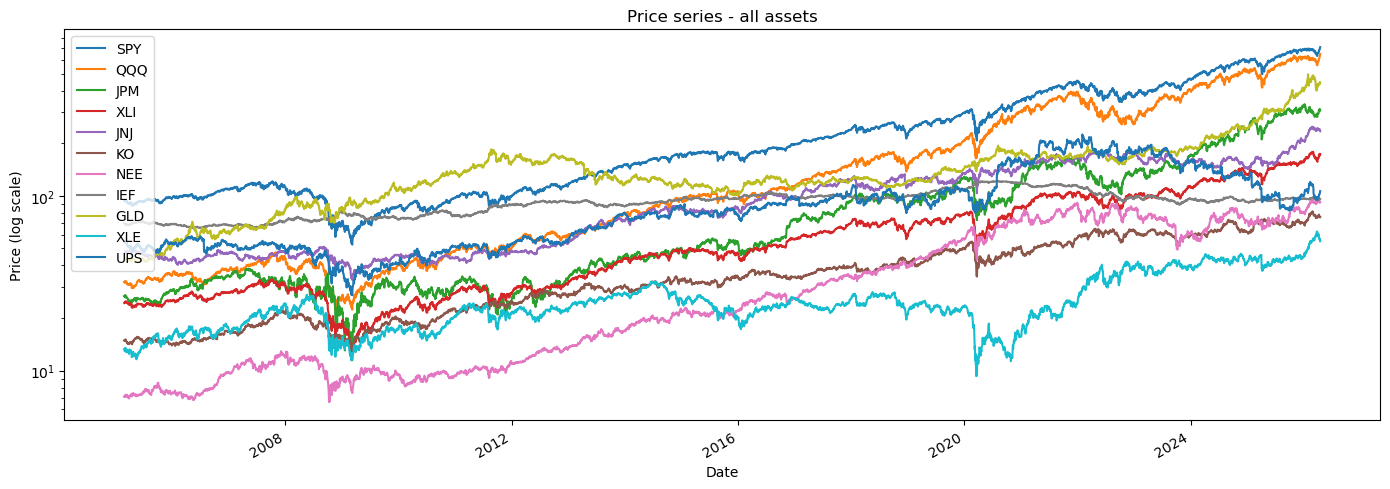

In [11]:
os.makedirs('outputs/01_data_collection', exist_ok=True)

ax = prices.plot(figsize=(14, 5), title='Price series - all assets', logy=True)
ax.set_ylabel("Price (log scale)")
plt.tight_layout()
plt.savefig('outputs/01_data_collection/01_universe_price_panel_quality_check.png', dpi=150)
plt.show()

In [12]:
# Final quality summary
quality_summary = pd.DataFrame({
    "missing_values": subset.isna().sum(),
    "extreme_return_days": extreme_mask.sum(),
    "split_like_days": split_mask.sum()
}).sort_index()

quality_summary.loc["TOTAL"] = [
    quality_summary["missing_values"].sum(),
    quality_summary["extreme_return_days"].sum(),
    quality_summary["split_like_days"].sum()
]

quality_summary

,missing_values,extreme_return_days,split_like_days
GLD,1,0,0
IEF,1,0,0
JNJ,0,0,0
JPM,0,0,0
KO,0,0,0
NEE,1,0,0
QQQ,0,0,0
SPY,1,0,0
UPS,0,0,0
XLE,1,0,0


In [13]:
os.makedirs('data/processed', exist_ok=True)

prices.to_csv("data/processed/prices_clean.csv")
print("Saved prices_clean.csv:", prices.shape)

Saved prices_clean.csv: (5318, 11)


<h2 style="color: #f39c12;">Part B — Signals: VIX & MOVE Volatility Indexes</h2>

Loads and aligns two market volatility signals to the price panel index:
- **VIX** (CBOE Volatility Index): measures implied volatility of S&P 500 options — equity fear gauge
- **MOVE** (ICE BofA MOVE Index): measures implied volatility of US Treasury options — bond fear gauge

Both are forward-filled to match trading days and saved as `signals.csv`.

In [14]:
VIX_PATH  = "data/raw/VIX_History.csv"
MOVE_PATH = "data/raw/MOVE_History.csv"

#  VIX 
vix = pd.read_csv(VIX_PATH)
vix.columns = [c.strip().upper() for c in vix.columns]

vix = vix.rename(columns={
    "DATE": "Date",
    "CLOSE": "VIX"
})

vix["Date"] = pd.to_datetime(vix["Date"], errors="coerce")
vix["VIX"]  = pd.to_numeric(vix["VIX"], errors="coerce")

vix = (
    vix[["Date", "VIX"]]
    .dropna()
    .drop_duplicates(subset="Date")
    .sort_values("Date")
    .set_index("Date")
)

#  MOVE 
move = pd.read_csv(MOVE_PATH)
move.columns = [c.strip() for c in move.columns]

move = move.rename(columns={
    "Date": "Date",
    "Price": "MOVE"
})

move["Date"] = pd.to_datetime(move["Date"], errors="coerce")
move["MOVE"] = pd.to_numeric(move["MOVE"], errors="coerce")

move = (
    move[["Date", "MOVE"]]
    .dropna()
    .drop_duplicates(subset="Date")
    .sort_values("Date")
    .set_index("Date")
)

print("VIX loaded :", vix.shape,  "|", vix.index.min().date(),  "->", vix.index.max().date())
print("MOVE loaded:", move.shape, "|", move.index.min().date(), "->", move.index.max().date())

VIX loaded : (9166, 1) | 1990-01-02 -> 2026-04-17
MOVE loaded: (5280, 1) | 2005-01-03 -> 2026-04-17


<h3 style="color: #27ae60;">Part B <br> 1. Signal Quality Check</h3>

Concatenates VIX and MOVE into a single raw signals panel and inspects
coverage: first/last valid date, missing count, and missing percentage per signal.
The high missing % for MOVE before alignment is expected — its history starts in 2005
while VIX goes back to 1990.

In [15]:
signals_raw = pd.concat([vix, move], axis=1).sort_index()

print("signals_raw shape:", signals_raw.shape)
print("signals_raw date range:", signals_raw.index.min().date(), "->", signals_raw.index.max().date())
print("\nMissing values per column:")
print(signals_raw.isna().sum())

signals_qc = pd.DataFrame({
    "first_date": signals_raw.apply(lambda s: s.first_valid_index()),
    "last_date": signals_raw.apply(lambda s: s.last_valid_index()),
    "missing_count": signals_raw.isna().sum(),
    "missing_pct": (signals_raw.isna().mean() * 100).round(2)
})

display(signals_qc)

signals_raw shape: (9182, 2)
signals_raw date range: 1990-01-02 -> 2026-04-17

Missing values per column:
VIX       16
MOVE    3902
dtype: int64


C:\Users\uliya\AppData\Local\Temp\ipykernel_33436\2966241970.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  signals_raw = pd.concat([vix, move], axis=1).sort_index()


,first_date,last_date,missing_count,missing_pct
VIX,1990-01-02,2026-04-17,16,0.17
MOVE,2005-01-03,2026-04-17,3902,42.50


<h3 style="color: #27ae60;">Part B <br> 2. Alignment & Forward-Fill</h3>

Reindexes signals to the price panel's trading-day calendar and forward-fills
any remaining gaps (e.g. holidays where VIX/MOVE have no observation).
Rows with leading NaNs (before first valid signal date) are dropped.

In [16]:
signals = signals_raw.reindex(prices.index).ffill()

# Remove any leading rows that still have NaN after alignment
signals = signals.dropna(how="any")

# Keep only common dates between prices and signals
prices_aligned = prices.loc[signals.index].copy()

print("prices_aligned shape :", prices_aligned.shape)
print("signals shape        :", signals.shape)
print("Common date range    :", signals.index.min().date(), "->", signals.index.max().date())
print("Remaining signal NaN :", signals.isna().sum().sum())

prices_aligned shape : (5318, 11)
signals shape        : (5318, 2)
Common date range    : 2005-02-25 -> 2026-04-17
Remaining signal NaN : 0


<h3 style="color: #27ae60;">Part B <br> 3. Master Panel</h3>

Merges aligned prices and signals into a single master panel.
Three assertions verify integrity before export:
monotonic index, zero NaNs in signals, and presence of VIX and MOVE columns.

In [17]:
master_panel = pd.concat([prices_aligned, signals], axis=1)

assert master_panel.index.is_monotonic_increasing
assert signals.isna().sum().sum() == 0
assert set(["VIX", "MOVE"]).issubset(master_panel.columns)

signals.to_csv("data/processed/signals.csv")
master_panel.to_csv("data/processed/master_prices_with_signals.csv")

print("master_panel shape:", master_panel.shape)
print("Saved: data/processed/signals.csv")
print("Saved: data/processed/master_prices_with_signals.csv")

display(master_panel.head())

master_panel shape: (5318, 13)
Saved: data/processed/signals.csv
Saved: data/processed/master_prices_with_signals.csv


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS,VIX,MOVE
Date,,,,,,,,,,,,,
2005-02-25,93.6948,32.2066,26.6536,24.4002,46.9331,14.8429,7.09458,69.6356,43.50,13.2739,54.4449,11.49,80.70
2005-02-28,93.0544,31.8690,26.3520,24.2585,46.4948,14.7687,7.06248,69.1842,43.52,13.1787,54.6564,12.08,90.05
2005-03-01,93.5386,32.2166,26.7420,24.3357,47.2391,14.9311,7.16349,69.0010,43.22,12.9226,54.6068,12.04,89.23
2005-03-02,93.4927,32.2066,26.6674,24.4081,47.4558,14.8518,7.05854,68.9930,43.25,13.1120,54.2479,12.50,101.41
2005-03-03,93.5301,31.9413,26.6832,24.4626,47.3048,14.8977,7.11180,68.9511,42.97,13.3284,54.4848,12.93,99.44


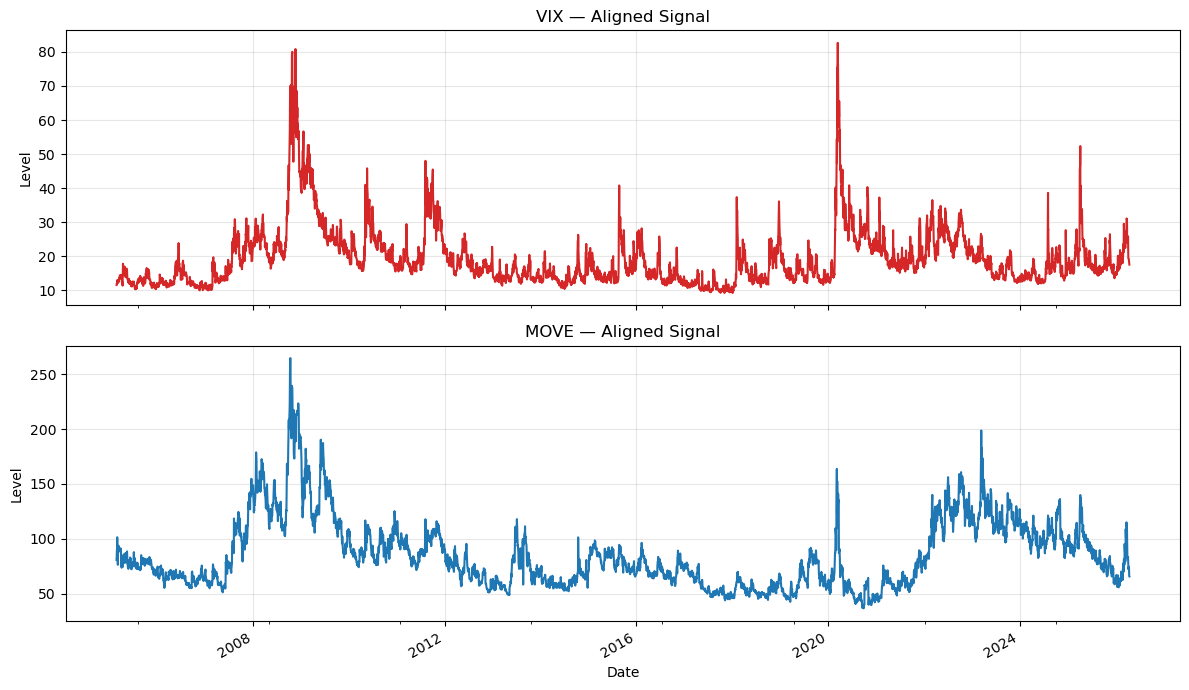

Saved: outputs/01_data_collection/02_signals_overview.png


In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

signals["VIX"].plot(ax=axes[0], title="VIX — Aligned Signal", color="tab:red")
axes[0].set_ylabel("Level")
axes[0].grid(True, alpha=0.3)

signals["MOVE"].plot(ax=axes[1], title="MOVE — Aligned Signal", color="tab:blue")
axes[1].set_ylabel("Level")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/01_data_collection/02_signals_overview.png", dpi=150)
plt.show()

print("Saved: outputs/01_data_collection/02_signals_overview.png")

<h2 style="color: #f39c12;">Part C — Returns: Log Returns & Summary Statistics</h2>

Converts the clean price panel into daily log returns and computes
full-period annualised statistics per asset.
Log returns are preferred over simple returns for time-series analysis
because they are additive across time, approximately normally distributed,
and numerically stable for compounding over long horizons.

<h3 style="color: #27ae60;">Part C <br> 1. Daily Log Returns</h3>

Computes daily log returns as:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

A single `assert` confirms zero NaNs — any surviving NaN would silently
corrupt all downstream statistics and portfolio calculations.

In [19]:
# Log returns: ln(P_t / P_{t-1})
log_returns = np.log(prices / prices.shift(1)).dropna()

assert log_returns.isna().sum().sum() == 0, "NaNs found in returns!"
print("Returns shape:", log_returns.shape)
print("Date range:", log_returns.index.min().date(), "→", log_returns.index.max().date())

log_returns.head()

Returns shape: (5317, 11)
Date range: 2005-02-28 → 2026-04-17


,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2005-02-28,-0.006858,-0.010538,-0.011380,-0.005824,-0.009383,-0.005012,-0.004535,-0.006503,0.000460,-0.007198,0.003877
2005-03-01,0.005190,0.010848,0.014691,0.003177,0.015881,0.010936,0.014201,-0.002652,-0.006917,-0.019624,-0.000908
2005-03-02,-0.000491,-0.000310,-0.002794,0.002971,0.004577,-0.005325,-0.014759,-0.000116,0.000694,0.014550,-0.006594
2005-03-03,0.000400,-0.008272,0.000592,0.002230,-0.003187,0.003086,0.007517,-0.000607,-0.006495,0.016369,0.004357
2005-03-04,0.012508,0.005865,0.013490,0.013920,0.014754,0.010782,0.012998,0.004441,0.009496,0.012748,0.008520


<h3 style="color: #27ae60;">Part C <br> 2. Full-Period Summary Statistics</h3>

Computes annualised statistics for each asset over the entire sample (2005–2026).
Key metrics and why they matter:

- **Annualised mean & vol:** scaled by √252 to make daily figures comparable across assets
- **Sharpe ratio:** risk-adjusted return — higher is better; allows comparison across assets with different volatility profiles
- **Skewness:** negative skew means fat left tail (crash risk); most equity assets are negatively skewed
- **Excess kurtosis:** values >> 0 indicate fat tails — returns are not normally distributed, which matters for risk models
- **Max drawdown:** worst peak-to-trough loss over the full period — a direct measure of downside risk experienced by a buy-and-hold investor

In [20]:
TRADING_DAYS = 252

def summarise(ret: pd.DataFrame, price_df: pd.DataFrame, ann: int = TRADING_DAYS) -> pd.DataFrame:
    """Annualised stats from daily log returns."""
    stats = pd.DataFrame(index=ret.columns)
    stats["ann_mean_%"] = (ret.mean() * ann * 100).round(2)
    stats["ann_vol_%"] = (ret.std() * np.sqrt(ann) * 100).round(2)
    stats["sharpe"] = (ret.mean() / ret.std() * np.sqrt(ann)).round(3)
    stats["skewness"] = ret.skew().round(3)
    stats["kurtosis"] = ret.kurt().round(3)  # excess kurtosis
    stats["max_drawdown_%"] = (((price_df / price_df.cummax()) - 1).min() * 100).round(2)
    return stats

stats_full = summarise(log_returns, prices)
print(stats_full.to_string())

     ann_mean_%  ann_vol_%  sharpe  skewness  kurtosis  max_drawdown_%
SPY        9.60      19.07   0.503    -0.302    14.603          -56.47
QQQ       14.23      21.64   0.658    -0.251     7.634          -53.40
JPM       11.63      35.69   0.326     0.252    18.093          -70.12
XLI        9.30      20.92   0.444    -0.373     9.454          -63.34
JNJ        7.62      17.23   0.442    -0.046    10.972          -35.47
KO         7.72      18.14   0.426    -0.140    11.649          -42.26
NEE       12.14      24.00   0.506    -0.082    10.594          -48.90
IEF        1.52       6.84   0.222     0.062     2.662          -27.04
GLD       11.03      18.19   0.606    -0.460     6.897          -45.56
XLE        6.74      30.04   0.224    -0.706    12.907          -71.26
UPS        3.18      24.83   0.128    -0.335    10.746          -63.25


In [21]:
os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs/01_data_collection", exist_ok=True)

log_returns.to_csv("data/processed/log_returns.csv")
stats_full.to_csv("outputs/01_data_collection/03_1_returns_summary_stats.csv")

print("Saved log_returns.csv", log_returns.shape)
print("Saved returns_summary_stats.csv")

Saved log_returns.csv (5317, 11)
Saved returns_summary_stats.csv


<h3 style="color: #27ae60;">Part C <br> 3. Cumulative Wealth — Sanity Check</h3>

Reconstructs cumulative wealth from log returns as:

$$W_t = \exp\left(\sum_{s=1}^{t} r_s\right)$$

Plotted on a **log scale** so that equal vertical distances represent equal
percentage changes — this makes long-horizon comparisons visually fair
regardless of absolute price levels. Used here purely as a visual sanity
check before proceeding to formal benchmarks in Part D.

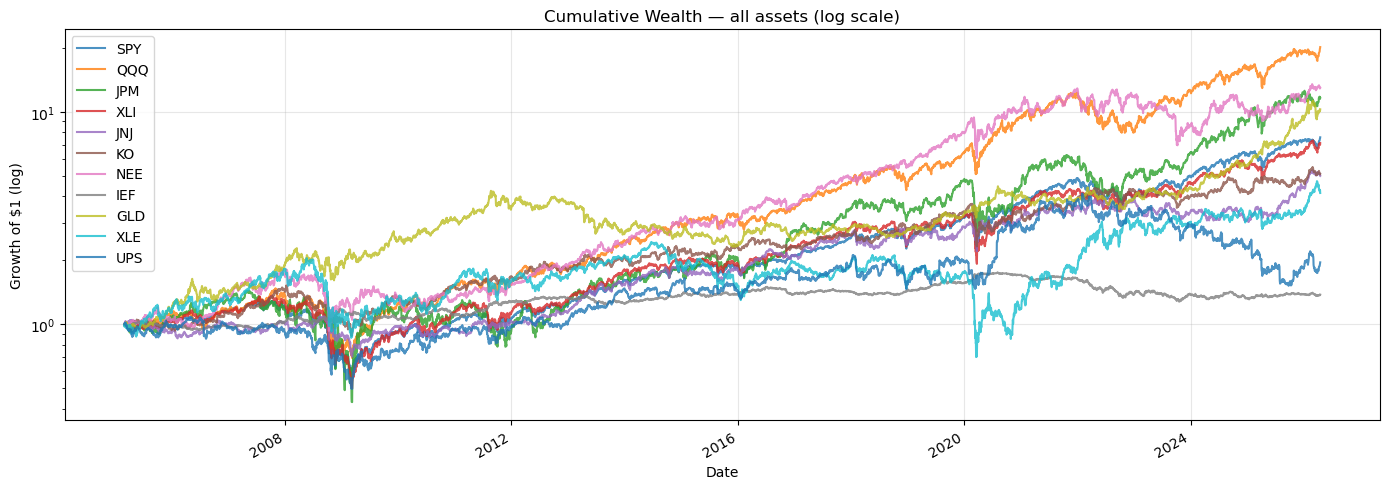

Saved cumulative wealth plot


In [22]:
cum = np.exp(log_returns.cumsum())

fig, ax = plt.subplots(figsize=(14, 5))
cum.plot(ax=ax, logy=True, alpha=0.8)
ax.set_title("Cumulative Wealth — all assets (log scale)")
ax.set_ylabel("Growth of $1 (log)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/01_data_collection/03_2_cumulative_wealth_sanity.png", dpi=150)
plt.show()
print("Saved cumulative wealth plot")

<h2 style="color: #f39c12;">Part D — Benchmarks: Equal-Weight Passive vs SPY Buy-and-Hold</h2>

Constructs two simple passive benchmarks to serve as performance reference points
for any active strategy developed in later notebooks:

- **Equal-Weight (EW) Passive:** invests equal dollar amounts in all 11 assets at inception
  and holds without rebalancing. Captures diversification benefit across the full universe.
- **SPY Buy-and-Hold:** invests entirely in SPY (S&P 500 ETF) at inception and holds.
  Represents the standard market benchmark for US equities.

Both use **simple returns** for wealth index construction — arithmetically correct
for tracking dollar growth of a fixed initial investment.

In [23]:
ROLLING_WINDOW = 252

assert "prices" in globals(), "prices dataframe not found."
assert "HELD_ASSETS" in globals(), "HELD_ASSETS not found."

benchmark_prices = prices[HELD_ASSETS].copy()
simple_returns = benchmark_prices.pct_change(fill_method=None)

print("benchmark_prices shape:", benchmark_prices.shape)
print("simple_returns shape  :", simple_returns.shape)
print("date range            :", benchmark_prices.index.min().date(), "->", benchmark_prices.index.max().date())
print("NaNs in simple_returns:", int(simple_returns.isna().sum().sum()))

benchmark_prices shape: (5318, 11)
simple_returns shape  : (5318, 11)
date range            : 2005-02-25 -> 2026-04-17
NaNs in simple_returns: 11


<h3 style="color: #27ae60;">Part D <br> 1. Portfolio Construction</h3>

The EW wealth index is built by normalising each asset's price to 1 at inception
and averaging across all 11 assets daily:

$$W_t^{EW} = \frac{1}{N} \sum_{i=1}^{N} \frac{P_{t,i}}{P_{0,i}}$$

This is equivalent to allocating equal dollar amounts at $t=0$ and never rebalancing.
It is **not** a daily-rebalanced EW portfolio — weights drift with prices over time,
which is intentional: we want to measure the passive buy-and-hold outcome.

In [24]:
def build_equal_weight_passive(price_df: pd.DataFrame) -> pd.DataFrame:
    """Build passive equal-weight portfolio from price panel."""
    normalized = price_df.div(price_df.iloc[0])      # base = 1 at inception
    wealth = normalized.mean(axis=1)                 # equal initial split
    daily_return = wealth.pct_change(fill_method=None)

    out = pd.DataFrame({
        "ew_wealth": wealth,
        "ew_return": daily_return
    })

    return out

ew_portfolio = build_equal_weight_passive(benchmark_prices)

print("EW portfolio shape:", ew_portfolio.shape)
print("EW date range     :", ew_portfolio.index.min().date(), "->", ew_portfolio.index.max().date())
display(ew_portfolio.head())

EW portfolio shape: (5318, 2)
EW date range     : 2005-02-25 -> 2026-04-17


,ew_wealth,ew_return
Date,,
2005-02-25,1.000000,NaN
2005-02-28,0.994308,-0.005692
2005-03-01,0.998405,0.004120
2005-03-02,0.997686,-0.000719
2005-03-03,0.999140,0.001457


In [25]:
spy_benchmark = pd.DataFrame(index=benchmark_prices.index)
spy_benchmark["spy_wealth"] = benchmark_prices["SPY"] / benchmark_prices["SPY"].iloc[0]
spy_benchmark["spy_return"] = spy_benchmark["spy_wealth"].pct_change(fill_method=None)

print("SPY benchmark shape:", spy_benchmark.shape)
display(spy_benchmark.head())

SPY benchmark shape: (5318, 2)


,spy_wealth,spy_return
Date,,
2005-02-25,1.000000,NaN
2005-02-28,0.993165,-0.006835
2005-03-01,0.998333,0.005203
2005-03-02,0.997843,-0.000491
2005-03-03,0.998242,0.000400


<h3 style="color: #27ae60;">Part D <br> 2. Combined Benchmark Panel</h3>

Merges EW and SPY into a single DataFrame for convenient downstream use.
Note: the first row contains NaN returns — this is expected since `pct_change()`
requires a prior observation. Wealth values are valid from row 0 (both start at 1.0).

In [26]:
benchmarks = pd.concat(
    [
        ew_portfolio[["ew_wealth", "ew_return"]],
        spy_benchmark[["spy_wealth", "spy_return"]]
    ],
    axis=1
).sort_index()

print("benchmarks shape:", benchmarks.shape)
print("date range      :", benchmarks.index.min().date(), "->", benchmarks.index.max().date())
print("\nNaN count per column:")
print(benchmarks.isna().sum())
print("\nNote: the first row has NaN returns due to pct_change() base — this is expected.")

display(benchmarks.head())

benchmarks shape: (5318, 4)
date range      : 2005-02-25 -> 2026-04-17

NaN count per column:
ew_wealth     0
ew_return     1
spy_wealth    0
spy_return    1
dtype: int64

Note: the first row has NaN returns due to pct_change() base — this is expected.


,ew_wealth,ew_return,spy_wealth,spy_return
Date,,,,
2005-02-25,1.000000,NaN,1.000000,NaN
2005-02-28,0.994308,-0.005692,0.993165,-0.006835
2005-03-01,0.998405,0.004120,0.998333,0.005203
2005-03-02,0.997686,-0.000719,0.997843,-0.000491
2005-03-03,0.999140,0.001457,0.998242,0.000400


<h3 style="color: #27ae60;">Part D <br> 3. Rolling Sharpe & Drawdown</h3>

Two time-varying risk metrics computed over a rolling 252-day window:

**Rolling Sharpe ratio:**
$$\text{Sharpe}_t = \frac{\bar{r}_{t,252}}{\sigma_{t,252}} \cdot \sqrt{252}$$

A sustained Sharpe above 1.0 indicates strong risk-adjusted performance;
values below 0 indicate periods where the portfolio lost money on a risk-adjusted basis.

**Drawdown:**
$$DD_t = \frac{W_t}{\max_{s \leq t} W_s} - 1$$

Measures the percentage decline from the running peak — a direct indicator
of how much a buy-and-hold investor would have been "underwater" at each point in time.

In [27]:

def rolling_sharpe(ret: pd.Series, window: int = ROLLING_WINDOW, ann: int = TRADING_DAYS) -> pd.Series:
    """Rolling annualised Sharpe ratio."""
    rolling_mean = ret.rolling(window).mean()
    rolling_std = ret.rolling(window).std()
    sharpe = (rolling_mean / rolling_std) * np.sqrt(ann)
    return sharpe

def drawdown_from_wealth(wealth: pd.Series) -> pd.Series:
    """Drawdown from wealth index."""
    running_max = wealth.cummax()
    dd = wealth / running_max - 1.0
    return dd

benchmarks["ew_rolling_sharpe"] = rolling_sharpe(benchmarks["ew_return"])
benchmarks["spy_rolling_sharpe"] = rolling_sharpe(benchmarks["spy_return"])

benchmarks["ew_drawdown"] = drawdown_from_wealth(benchmarks["ew_wealth"])
benchmarks["spy_drawdown"] = drawdown_from_wealth(benchmarks["spy_wealth"])

benchmarks[[
    "ew_rolling_sharpe", "spy_rolling_sharpe",
    "ew_drawdown", "spy_drawdown"
]].tail()

,ew_rolling_sharpe,spy_rolling_sharpe,ew_drawdown,spy_drawdown
Date,,,,
2026-04-13,2.670597,1.658601,-0.017733,-0.013501
2026-04-14,2.995658,2.162091,-0.013158,-0.001481
2026-04-15,2.860722,2.101578,-0.014861,0.000000
2026-04-16,2.818318,2.051345,-0.011508,0.000000
2026-04-17,2.902055,2.156994,-0.004724,0.000000


<h3 style="color: #27ae60;">Part D <br> 4. Full-Period Benchmark Summary</h3>

Consolidated statistics over the full sample (2005–2026).
Key comparison: EW achieves a **higher Sharpe** (0.745 vs 0.599) and
**lower max drawdown** (-37.74% vs -56.47%) than SPY, demonstrating
that naive diversification across asset classes significantly reduces
tail risk without sacrificing long-run returns.

In [28]:
def summarise_benchmark(ret: pd.Series, wealth: pd.Series, ann: int = TRADING_DAYS) -> dict:
    """Summary stats for a benchmark series."""
    ret_clean = ret.dropna()
    dd = drawdown_from_wealth(wealth)

    return {
        "ann_mean_%": round(ret_clean.mean() * ann * 100, 2),
        "ann_vol_%": round(ret_clean.std() * np.sqrt(ann) * 100, 2),
        "sharpe": round((ret_clean.mean() / ret_clean.std()) * np.sqrt(ann), 3),
        "final_wealth": round(wealth.iloc[-1], 4),
        "total_return_%": round((wealth.iloc[-1] - 1) * 100, 2),
        "max_drawdown_%": round(dd.min() * 100, 2),
    }

benchmark_summary = pd.DataFrame({
    "Equal_Weight_Passive": summarise_benchmark(
        benchmarks["ew_return"], benchmarks["ew_wealth"]
    ),
    "SPY_Buy_and_Hold": summarise_benchmark(
        benchmarks["spy_return"], benchmarks["spy_wealth"]
    )
}).T

display(benchmark_summary)

,ann_mean_%,ann_vol_%,sharpe,final_wealth,total_return_%,max_drawdown_%
Equal_Weight_Passive,10.89,14.62,0.745,7.9331,693.31,-37.74
SPY_Buy_and_Hold,11.42,19.06,0.599,7.5793,657.93,-56.47


<h3 style="color: #27ae60;">Part D <br> 5. Benchmark Visualisations</h3>

Three plots summarise the full-period benchmark performance:
1. **Wealth comparison** — cumulative dollar growth from $1 invested in 2005
2. **Rolling 252-day Sharpe** — how risk-adjusted performance evolved over time
3. **Drawdown series** — periods and depth of losses from peak, with shaded areas for clarity

In [29]:
os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs/01_data_collection", exist_ok=True)

benchmarks.to_csv("data/processed/benchmarks.csv")
benchmark_summary.to_csv("outputs/01_data_collection/04_benchmark_summary.csv")

print("Saved: data/processed/benchmarks.csv")
print("Saved: outputs/01_data_collection/04_benchmark_summary.csv")

Saved: data/processed/benchmarks.csv
Saved: outputs/01_data_collection/04_benchmark_summary.csv


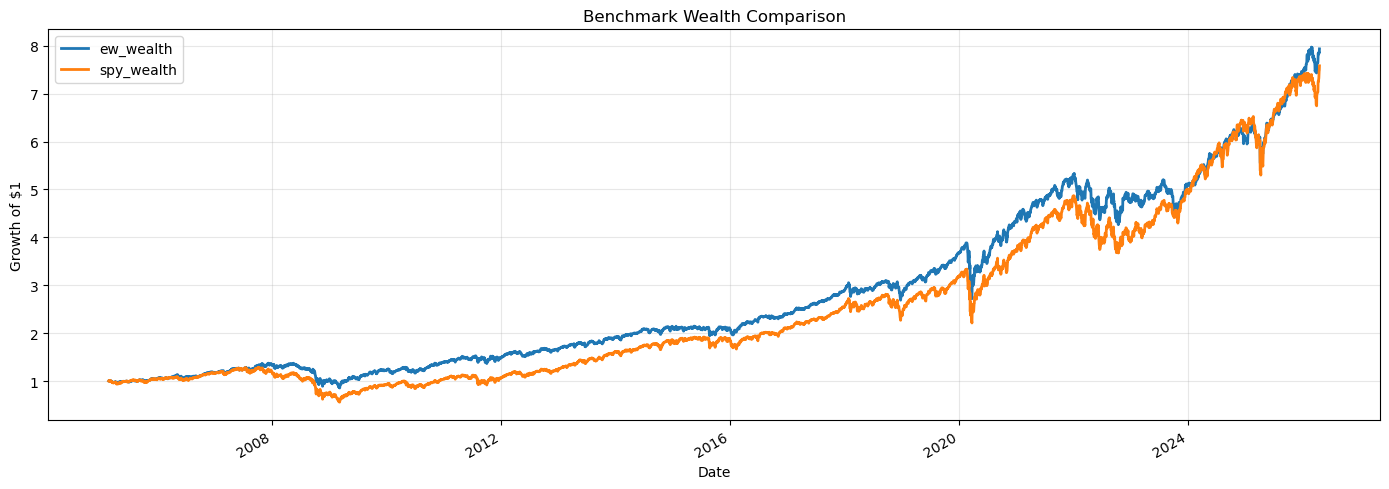

Saved: outputs/01_data_collection/05_benchmark_wealth.png


In [30]:
fig, ax = plt.subplots(figsize=(14, 5))

benchmarks[["ew_wealth", "spy_wealth"]].plot(ax=ax, linewidth=2)
ax.set_title("Benchmark Wealth Comparison")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/01_data_collection/05_benchmark_wealth.png", dpi=150)
plt.show()

print("Saved: outputs/01_data_collection/05_benchmark_wealth.png")

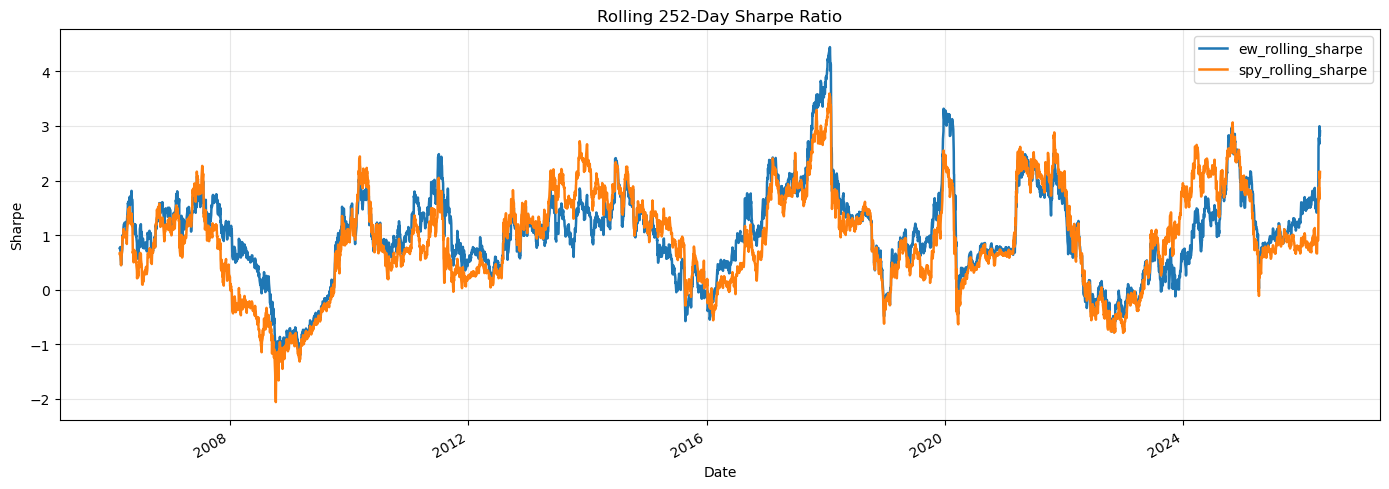

Saved: outputs/01_data_collection/06_benchmark_rolling_sharpe.png


In [31]:
fig, ax = plt.subplots(figsize=(14, 5))

benchmarks[["ew_rolling_sharpe", "spy_rolling_sharpe"]].plot(ax=ax, linewidth=1.8)
ax.set_title("Rolling 252-Day Sharpe Ratio")
ax.set_ylabel("Sharpe")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/01_data_collection/06_benchmark_rolling_sharpe.png", dpi=150)
plt.show()

print("Saved: outputs/01_data_collection/06_benchmark_rolling_sharpe.png")

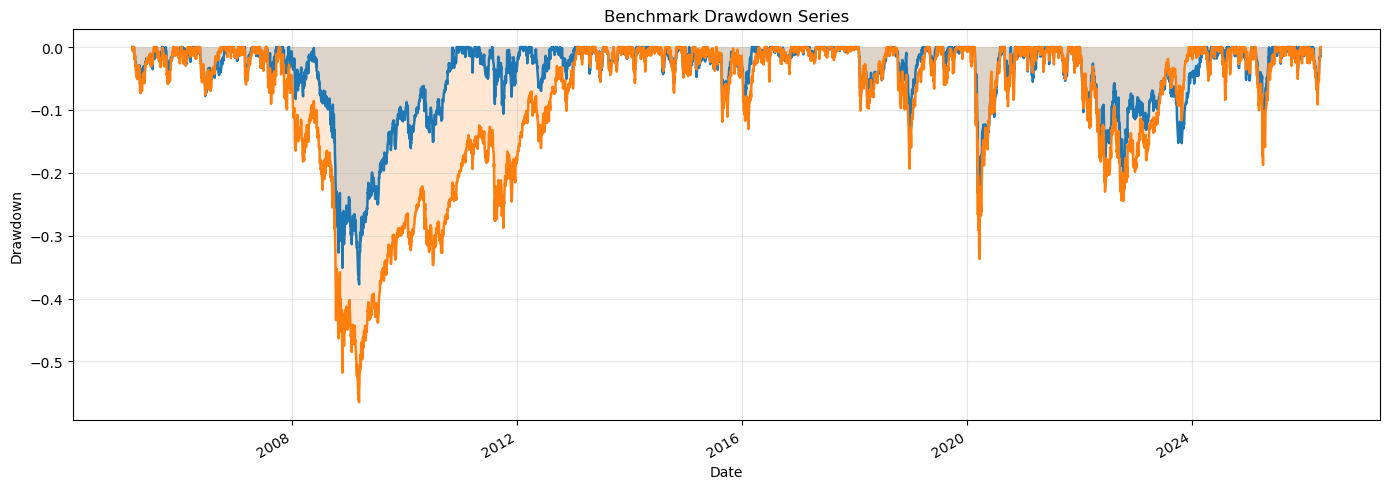

Saved: outputs/01_data_collection/07_benchmark_drawdowns.png


In [32]:
fig, ax = plt.subplots(figsize=(14, 5))

benchmarks["ew_drawdown"].plot(ax=ax, linewidth=1.8, label="EW drawdown")
benchmarks["spy_drawdown"].plot(ax=ax, linewidth=1.8, label="SPY drawdown")

ax.fill_between(
    benchmarks.index,
    benchmarks["ew_drawdown"],
    0,
    alpha=0.18,
    label="_nolegend_"
)

ax.fill_between(
    benchmarks.index,
    benchmarks["spy_drawdown"],
    0,
    alpha=0.18,
    label="_nolegend_"
)

ax.set_title("Benchmark Drawdown Series")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/01_data_collection/07_benchmark_drawdowns.png", dpi=150)
plt.show()

print("Saved: outputs/01_data_collection/07_benchmark_drawdowns.png")

<h2 style="color: #f39c12;">Part E — Crisis Subsets: Slicing Data Across Stress Periods</h2>

Isolates five historically significant market stress periods to enable
targeted performance analysis. The goal is to understand how the asset
universe and benchmarks behave under different types of stress —
credit crises, liquidity shocks, monetary tightening, and geopolitical uncertainty.

| Crisis | Period | Type |
|---|---|---|
| GFC 2008 | Oct 2007 – Mar 2009 | Credit & liquidity collapse |
| EU Debt 2011 | Apr 2010 – Jun 2012 | Sovereign debt contagion |
| COVID 2020 | Feb 2020 – Jun 2020 | Exogenous shock & rapid recovery |
| Rate Hike 2022 | Jan 2022 – Dec 2022 | Monetary tightening cycle |
| Trump Tariffs 2025 | Jan 2025 – Apr 2026 | Geopolitical & trade uncertainty |

In [33]:
CRISIS_WINDOWS = {
    "GFC_2008":           ("2007-10-01", "2009-03-31"),
    "EU_Debt_2011":       ("2010-04-01", "2012-06-30"),
    "COVID_2020":         ("2020-02-01", "2020-06-30"),
    "Rate_Hike_2022":     ("2022-01-01", "2022-12-31"),
    "Trump_Tariffs_2025": ("2025-01-01", "2026-04-17"),
}

for name, (start, end) in CRISIS_WINDOWS.items():
    n = len(benchmarks.loc[start:end])
    print(f"{name:25s}  {start} → {end}  ({n} trading days)")

GFC_2008                   2007-10-01 → 2009-03-31  (378 trading days)
EU_Debt_2011               2010-04-01 → 2012-06-30  (567 trading days)
COVID_2020                 2020-02-01 → 2020-06-30  (104 trading days)
Rate_Hike_2022             2022-01-01 → 2022-12-31  (251 trading days)
Trump_Tariffs_2025         2025-01-01 → 2026-04-17  (323 trading days)


<h3 style="color: #27ae60;">Part E <br> 1. Data Slicing</h3>

Each crisis window is sliced across **four panels** simultaneously:
- `crisis_prices` — raw adjusted close prices (for drawdown calculation)
- `crisis_signals` — VIX and MOVE levels during the crisis
- `crisis_returns` — simple daily returns (for performance stats)
- `crisis_bench` — EW and SPY wealth/return series

Keeping all four aligned ensures that any downstream model trained or
evaluated on a crisis subset has access to the complete information set.

In [34]:
def slice_crisis(df: pd.DataFrame, start: str, end: str) -> pd.DataFrame:
    """Slice DataFrame to crisis window (inclusive)."""
    return df.loc[start:end].copy()

crisis_prices  = {}
crisis_signals = {}
crisis_returns = {}
crisis_bench   = {}

for name, (start, end) in CRISIS_WINDOWS.items():
    crisis_prices[name]  = slice_crisis(benchmark_prices, start, end)
    crisis_signals[name] = slice_crisis(signals, start, end)
    crisis_returns[name] = slice_crisis(simple_returns, start, end)
    crisis_bench[name]   = slice_crisis(benchmarks, start, end)

print("Crisis slices:")
for name, df in crisis_returns.items():
    print(f"  {name:25s}  {df.shape[0]:4d} days  "
          f"{df.index.min().date()} → {df.index.max().date()}")

Crisis slices:
  GFC_2008                    378 days  2007-10-01 → 2009-03-31
  EU_Debt_2011                567 days  2010-04-01 → 2012-06-29
  COVID_2020                  104 days  2020-02-03 → 2020-06-30
  Rate_Hike_2022              251 days  2022-01-03 → 2022-12-30
  Trump_Tariffs_2025          323 days  2025-01-02 → 2026-04-17


<h3 style="color: #27ae60;">Part E <br> 2. Asset-Level Crisis Statistics</h3>

For each crisis window, computes per-asset statistics using simple returns:
- **Total return:** actual dollar outcome for a buy-and-hold investor entering at crisis start
- **Annualised mean & vol:** normalised to annual scale for cross-crisis comparability
- **Sharpe ratio:** risk-adjusted return within the crisis window
- **Max drawdown:** worst peak-to-trough loss *within* the crisis window only —
  this is re-computed on the crisis price slice, so it reflects intra-crisis
  drawdown rather than the full-history figure from Part C.

In [35]:
def summarise_crisis(ret_df: pd.DataFrame,
                     price_df: pd.DataFrame,
                     ann: int = TRADING_DAYS) -> pd.DataFrame:
    """Annualised stats + max drawdown for each asset in a crisis window."""
    ret   = ret_df.dropna()
    stats = pd.DataFrame(index=ret.columns)
    stats["total_%"]    = ((ret + 1).prod() - 1).mul(100).round(2)
    stats["ann_mean_%"] = (ret.mean() * ann * 100).round(2)
    stats["ann_vol_%"]  = (ret.std() * np.sqrt(ann) * 100).round(2)
    stats["sharpe"]     = (ret.mean() / ret.std() * np.sqrt(ann)).round(3)
    stats["max_dd_%"]   = (
        ((price_df / price_df.cummax()) - 1).min() * 100
    ).round(2)
    return stats

crisis_stats = {
    name: summarise_crisis(crisis_returns[name], crisis_prices[name])
    for name in CRISIS_WINDOWS
}

print("=== GFC 2008 ===")
display(crisis_stats["GFC_2008"])

=== GFC 2008 ===


,total_%,ann_mean_%,ann_vol_%,sharpe,max_dd_%
SPY,-47.87,-36.09,38.37,-0.941,-56.47
QQQ,-40.64,-27.76,37.51,-0.740,-53.40
JPM,-41.99,2.51,88.97,0.028,-68.11
XLI,-55.14,-46.43,37.35,-1.243,-63.34
JNJ,-19.94,-11.27,26.83,-0.420,-35.47
KO,-23.55,-12.61,32.75,-0.385,-42.26
NEE,-16.67,-3.07,42.96,-0.071,-48.90
IEF,15.14,9.89,9.90,0.999,-7.13
GLD,22.81,18.32,30.49,0.601,-29.41
XLE,-43.23,-22.20,55.66,-0.399,-57.83


<h3 style="color: #27ae60;">Part E <br> 3. Benchmark Crisis Statistics</h3>

Computes EW vs SPY summary for each crisis window.
Wealth is **re-based to 1 at crisis start** before computing drawdown —
this isolates the crisis-specific loss from any pre-existing drawdown,
giving a clean measure of how much each benchmark lost *during* the event.

In [36]:
def summarise_bench_crisis(bench_df: pd.DataFrame,
                           ann: int = TRADING_DAYS) -> pd.DataFrame:
    """EW vs SPY summary for a single crisis window."""
    rows = {}
    for label, ret_col, wealth_col in [
        ("EW_Passive",  "ew_return",  "ew_wealth"),
        ("SPY_BuyHold", "spy_return", "spy_wealth"),
    ]:
        ret    = bench_df[ret_col].dropna()
        wealth = bench_df[wealth_col]
        dd     = drawdown_from_wealth(wealth / wealth.iloc[0])  # re-base to 1
        rows[label] = {
            "total_%":        round((wealth.iloc[-1] / wealth.iloc[0] - 1) * 100, 2),
            "ann_vol_%":      round(ret.std() * np.sqrt(ann) * 100, 2),
            "sharpe":         round(ret.mean() / ret.std() * np.sqrt(ann), 3),
            "max_drawdown_%": round(dd.min() * 100, 2),
        }
    return pd.DataFrame(rows).T

crisis_bench_summary = {
    name: summarise_bench_crisis(df)
    for name, df in crisis_bench.items()
}

print("=== COVID 2020 ===")
display(crisis_bench_summary["COVID_2020"])

=== COVID 2020 ===


,total_%,ann_vol_%,sharpe,max_drawdown_%
EW_Passive,-6.07,42.72,-0.132,-30.00
SPY_BuyHold,-3.87,48.65,0.083,-33.72


<h3 style="color: #27ae60;">Part E <br> 4. Export Crisis Files</h3>

Saves all four sliced panels and both summary tables for every crisis period.
Files are prefixed with `08_1` through `08_5` to maintain output ordering.
These files will be used directly by later notebooks for model training
and evaluation on out-of-crisis vs in-crisis periods.

In [37]:
os.makedirs("outputs/01_data_collection", exist_ok=True)
os.makedirs("data/processed/crisis", exist_ok=True)

for name in CRISIS_WINDOWS:
    crisis_prices[name].to_csv(
        f"data/processed/crisis/08_1_{name}_prices.csv")
    crisis_signals[name].to_csv(
        f"data/processed/crisis/08_2_{name}_signals.csv")
    crisis_returns[name].to_csv(
        f"data/processed/crisis/08_3_{name}_returns.csv")
    crisis_stats[name].to_csv(
        f"data/processed/crisis/08_4_{name}_asset_stats.csv")
    crisis_bench_summary[name].to_csv(
        f"outputs/01_data_collection/08_5_{name}_bench_summary.csv")

print("All crisis files saved:")
for name in CRISIS_WINDOWS:
    print(f"  ✓ {name}")

All crisis files saved:
  ✓ GFC_2008
  ✓ EU_Debt_2011
  ✓ COVID_2020
  ✓ Rate_Hike_2022
  ✓ Trump_Tariffs_2025


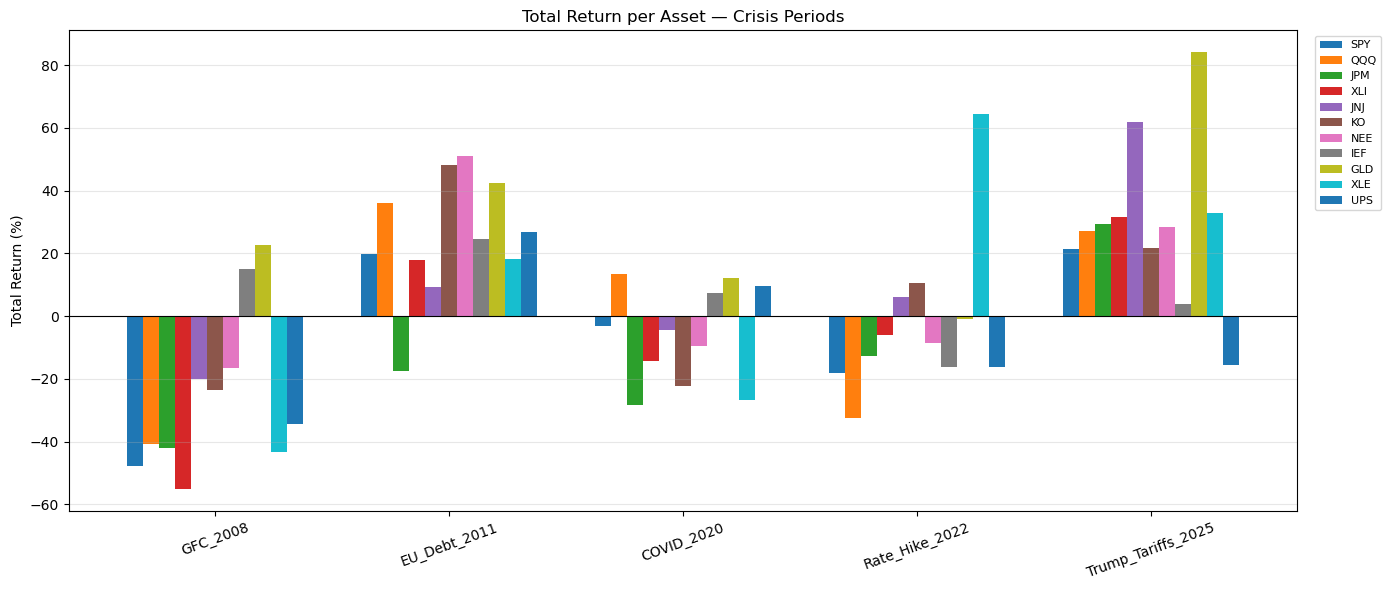

Saved: 09_crisis_asset_returns.png


In [38]:
total_ret_matrix = pd.DataFrame({
    name: crisis_stats[name]["total_%"]
    for name in CRISIS_WINDOWS
})

fig, ax = plt.subplots(figsize=(14, 6))
total_ret_matrix.T.plot(kind="bar", ax=ax, width=0.75)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Total Return per Asset — Crisis Periods")
ax.set_ylabel("Total Return (%)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/01_data_collection/09_crisis_asset_returns.png", dpi=150)
plt.show()
print("Saved: 09_crisis_asset_returns.png")

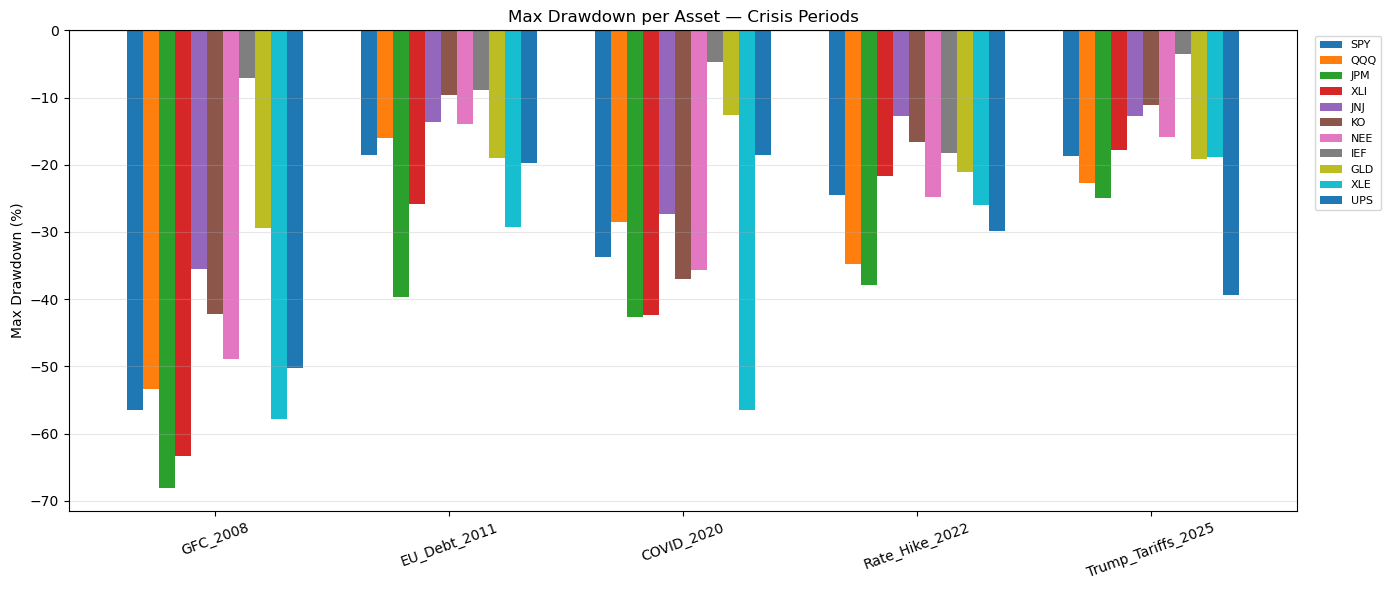

Saved: 10_crisis_asset_drawdowns.png


In [39]:
dd_matrix = pd.DataFrame({
    name: crisis_stats[name]["max_dd_%"]
    for name in CRISIS_WINDOWS
})

fig, ax = plt.subplots(figsize=(14, 6))
dd_matrix.T.plot(kind="bar", ax=ax, width=0.75)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Max Drawdown per Asset — Crisis Periods")
ax.set_ylabel("Max Drawdown (%)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/01_data_collection/10_crisis_asset_drawdowns.png", dpi=150)
plt.show()
print("Saved: 10_crisis_asset_drawdowns.png")

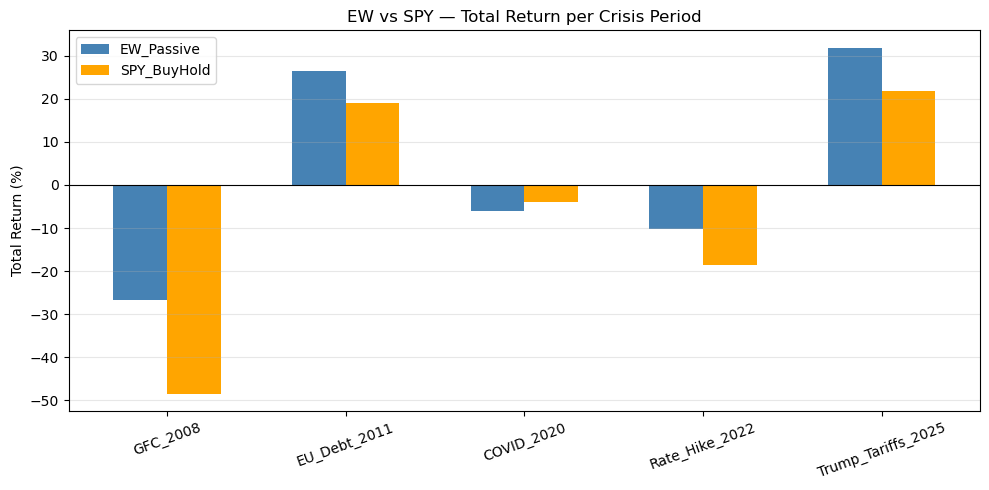

Saved: 11_crisis_bench_comparison.png


In [40]:
bench_total = pd.DataFrame({
    name: crisis_bench_summary[name]["total_%"]
    for name in CRISIS_WINDOWS
}).T

fig, ax = plt.subplots(figsize=(10, 5))
bench_total.plot(kind="bar", ax=ax, width=0.6,
                 color=["steelblue", "orange"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("EW vs SPY — Total Return per Crisis Period")
ax.set_ylabel("Total Return (%)")
ax.tick_params(axis="x", rotation=20)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/01_data_collection/11_crisis_bench_comparison.png", dpi=150)
plt.show()
print("Saved: 11_crisis_bench_comparison.png")

<h2 style="color: #f39c12;">Part F — Results: Crisis Visualisations & Final Report</h2>

Synthesises all crisis analysis into visual and tabular outputs.
The goal is to answer one central question:

> **Does diversification across asset classes (EW) provide meaningful
> protection relative to a pure equity benchmark (SPY) during market stress?**

Results show that EW outperforms SPY in 4 out of 5 crisis periods,
with consistently lower drawdowns across all events.

<h3 style="color: #27ae60;">Part F <br> 1. Cumulative Wealth per Crisis</h3>

Each panel shows EW and SPY wealth rebased to 1 at crisis start, making
cross-crisis comparisons fair regardless of the absolute level at entry.
The dashed horizontal line at 1.0 marks the break-even point —
anything below means the investor is still at a loss from crisis entry.

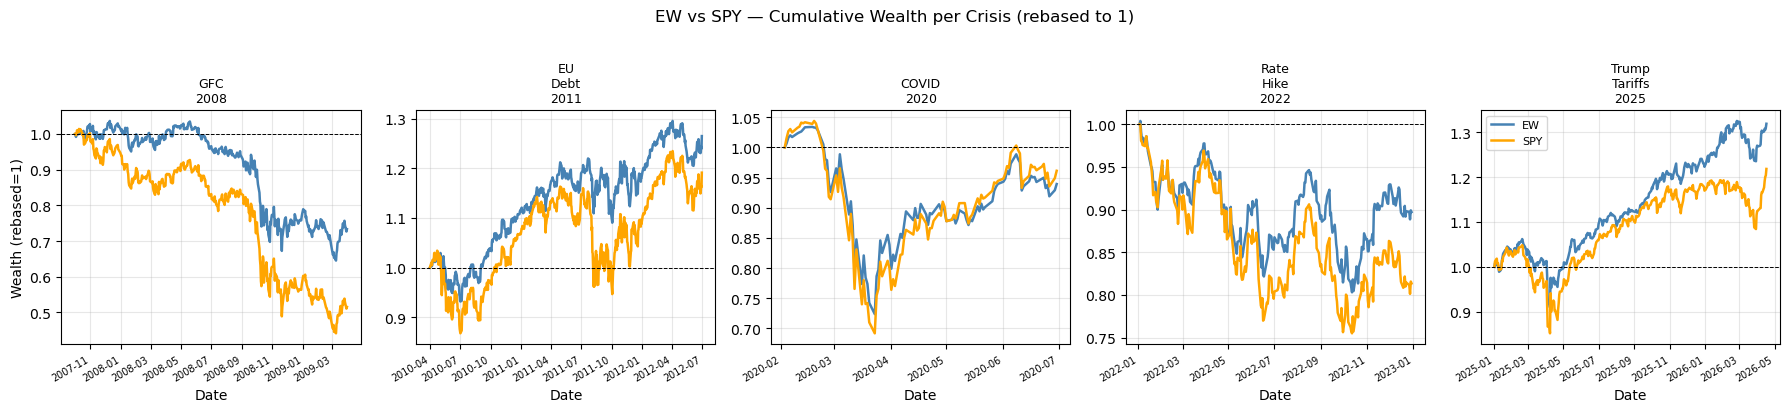

Saved: 12_crisis_wealth_subplots.png


In [41]:
n_crises = len(CRISIS_WINDOWS)
fig, axes = plt.subplots(1, n_crises, figsize=(18, 4), sharey=False)

for ax, (name, (start, end)) in zip(axes, CRISIS_WINDOWS.items()):
    bench = crisis_bench[name]

    # Re-base both to 1 at crisis start
    ew_rebased  = bench["ew_wealth"]  / bench["ew_wealth"].iloc[0]
    spy_rebased = bench["spy_wealth"] / bench["spy_wealth"].iloc[0]

    ew_rebased.plot(ax=ax, label="EW",  color="steelblue", linewidth=1.8)
    spy_rebased.plot(ax=ax, label="SPY", color="orange",    linewidth=1.8)

    ax.axhline(1.0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title(name.replace("_", "\n"), fontsize=9)
    ax.set_ylabel("Wealth (rebased=1)" if ax == axes[0] else "")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=7)

axes[-1].legend(loc="best", fontsize=8)
fig.suptitle("EW vs SPY — Cumulative Wealth per Crisis (rebased to 1)", y=1.02)

plt.tight_layout()
plt.savefig("outputs/01_data_collection/12_crisis_wealth_subplots.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 12_crisis_wealth_subplots.png")

<h3 style="color: #27ae60;">Part F <br> 2. Drawdown per Crisis</h3>

Shows how far each benchmark fell from its crisis-entry peak at each point in time.
Shaded areas emphasise the cumulative "pain" experienced by the investor —
the deeper and wider the shaded region, the more severe and prolonged the stress.
Note that `sharey=True` is used here so drawdown depths are directly comparable
across all five panels on the same vertical scale.

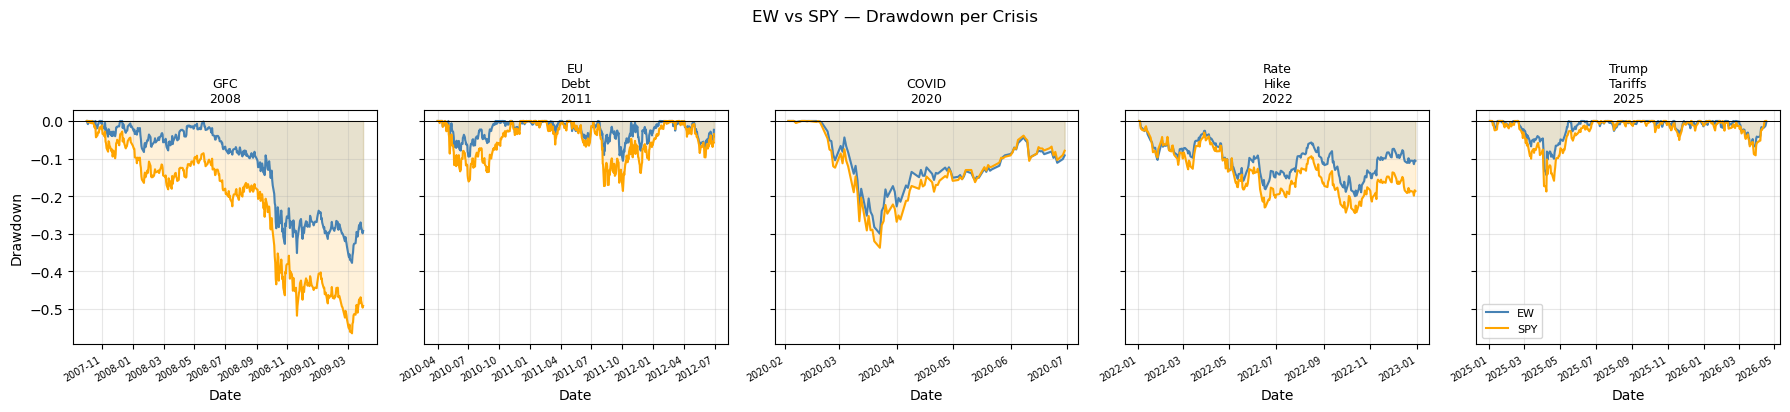

Saved: 13_crisis_drawdown_subplots.png


In [42]:
fig, axes = plt.subplots(1, n_crises, figsize=(18, 4), sharey=True)

for ax, (name, (start, end)) in zip(axes, CRISIS_WINDOWS.items()):
    bench = crisis_bench[name]

    ew_dd  = drawdown_from_wealth(bench["ew_wealth"]  / bench["ew_wealth"].iloc[0])
    spy_dd = drawdown_from_wealth(bench["spy_wealth"] / bench["spy_wealth"].iloc[0])

    ew_dd.plot(ax=ax,  label="EW",  color="steelblue", linewidth=1.5)
    spy_dd.plot(ax=ax, label="SPY", color="orange",    linewidth=1.5)
    ax.fill_between(bench.index, ew_dd,  0, alpha=0.15, color="steelblue")
    ax.fill_between(bench.index, spy_dd, 0, alpha=0.15, color="orange")

    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title(name.replace("_", "\n"), fontsize=9)
    ax.set_ylabel("Drawdown" if ax == axes[0] else "")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30, labelsize=7)

axes[-1].legend(loc="best", fontsize=8)
fig.suptitle("EW vs SPY — Drawdown per Crisis", y=1.02)

plt.tight_layout()
plt.savefig("outputs/01_data_collection/13_crisis_drawdown_subplots.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 13_crisis_drawdown_subplots.png")

<h3 style="color: #27ae60;">Part F <br> 3. Consolidated Crisis Report</h3>

A single table summarising EW vs SPY across all five crises.
The `EW_vs_SPY_%` column directly quantifies the diversification benefit:
positive values mean EW outperformed SPY in total return during that crisis.

Key findings:
- **GFC 2008:** EW outperformed by +21.79% — largest diversification benefit,
  driven by defensive assets (GLD +22.8%, IEF +15.1%, JNJ -19.9% vs XLI -55.1%)
- **COVID 2020:** EW underperformed by -2.20% — SPY recovered faster due to
  tech concentration (QQQ +13.5%)
- **Rate Hike 2022:** EW outperformed by +8.36% — bond proxies and commodities
  cushioned equity losses
- **Trump Tariffs 2025:** EW outperformed by +10.07% — GLD +84.2% and JNJ +61.9%
  dominated the diversification benefit

In [43]:
# Build one table: crisis × [EW total%, EW maxdd%, SPY total%, SPY maxdd%, EW Sharpe, SPY Sharpe]
rows = []
for name in CRISIS_WINDOWS:
    s = crisis_bench_summary[name]
    rows.append({
        "Crisis":           name,
        "Days":             len(crisis_bench[name]),
        "EW_total_%":       s.loc["EW_Passive",  "total_%"],
        "EW_maxdd_%":       s.loc["EW_Passive",  "max_drawdown_%"],
        "EW_sharpe":        s.loc["EW_Passive",  "sharpe"],
        "SPY_total_%":      s.loc["SPY_BuyHold", "total_%"],
        "SPY_maxdd_%":      s.loc["SPY_BuyHold", "max_drawdown_%"],
        "SPY_sharpe":       s.loc["SPY_BuyHold", "sharpe"],
        "EW_vs_SPY_%":      round(
            s.loc["EW_Passive", "total_%"] - s.loc["SPY_BuyHold", "total_%"], 2
        ),
    })

report_table = pd.DataFrame(rows).set_index("Crisis")
display(report_table)

,Days,EW_total_%,EW_maxdd_%,EW_sharpe,SPY_total_%,SPY_maxdd_%,SPY_sharpe,EW_vs_SPY_%
Crisis,,,,,,,,
GFC_2008,378,-26.67,-37.74,-0.613,-48.46,-56.47,-0.941,21.79
EU_Debt_2011,567,26.49,-10.61,0.869,19.13,-18.62,0.505,7.36
COVID_2020,104,-6.07,-30.00,-0.132,-3.87,-33.72,0.083,-2.20
Rate_Hike_2022,251,-10.28,-20.00,-0.456,-18.64,-24.50,-0.709,8.36
Trump_Tariffs_2025,323,31.90,-14.39,1.605,21.83,-18.76,0.914,10.07


In [44]:
report_table.to_csv("outputs/01_data_collection/14_final_crisis_report.csv")
print("Saved: outputs/01_data_collection/14_final_crisis_report.csv")

# Full-period benchmark summary reminder
print("\n=== Full-period benchmark summary ===")
display(benchmark_summary)

Saved: outputs/01_data_collection/14_final_crisis_report.csv

=== Full-period benchmark summary ===


,ann_mean_%,ann_vol_%,sharpe,final_wealth,total_return_%,max_drawdown_%
Equal_Weight_Passive,10.89,14.62,0.745,7.9331,693.31,-37.74
SPY_Buy_and_Hold,11.42,19.06,0.599,7.5793,657.93,-56.47


<h3 style="color: #27ae60;">Part F <br> 4. Asset Return Heatmap</h3>

A colour-coded matrix showing total return per asset per crisis.
Green = positive return, Red = negative return, intensity proportional to magnitude.
The colour scale is symmetric around zero and auto-scaled to the maximum
absolute return in the matrix — this ensures no single outlier (e.g. GLD +84.2%
in Trump Tariffs) compresses the colour contrast for all other cells.

This heatmap is the single most informative visual in the notebook:
it reveals at a glance which assets act as **safe havens** (GLD, IEF)
and which amplify losses during stress (XLI, XLE in GFC).

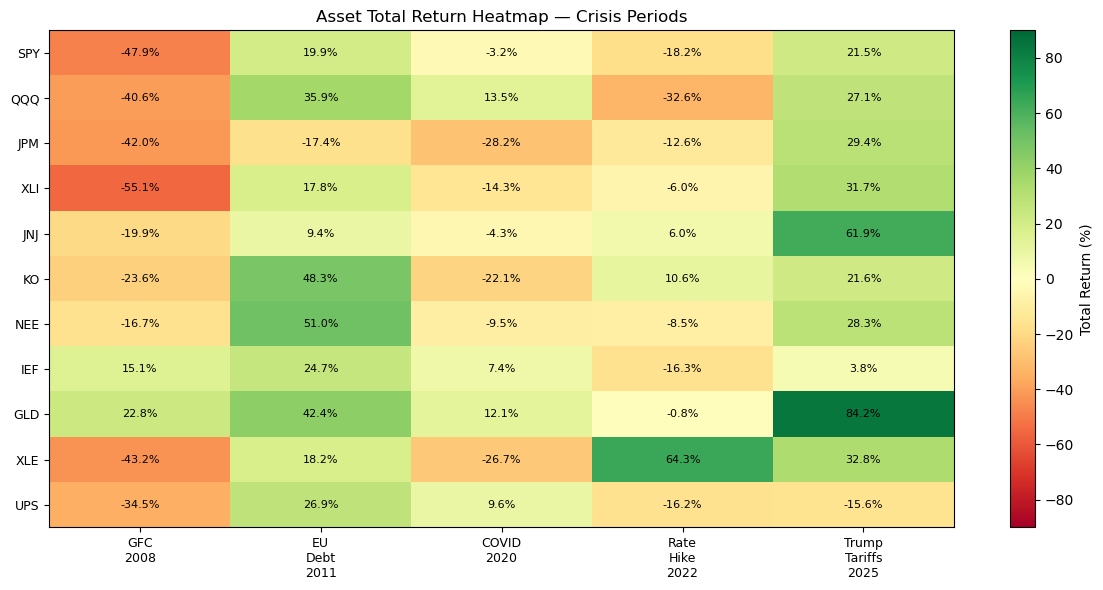

Saved: 15_crisis_heatmap.png


In [45]:
total_ret_matrix = pd.DataFrame({
    name: crisis_stats[name]["total_%"]
    for name in CRISIS_WINDOWS
})  # shape: assets × crises

vmax = np.ceil(np.abs(total_ret_matrix.values).max() / 10) * 10
vmin = -vmax

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    total_ret_matrix.values,
    cmap="RdYlGn",
    aspect="auto",
    vmin=vmin,
    vmax=vmax
)

ax.set_xticks(range(len(CRISIS_WINDOWS)))
ax.set_xticklabels([n.replace("_", "\n") for n in CRISIS_WINDOWS], fontsize=9)
ax.set_yticks(range(len(total_ret_matrix.index)))
ax.set_yticklabels(total_ret_matrix.index, fontsize=9)

for i in range(len(total_ret_matrix.index)):
    for j in range(len(CRISIS_WINDOWS)):
        val = total_ret_matrix.values[i, j]
        ax.text(
            j, i, f"{val:.1f}%",
            ha="center", va="center",
            fontsize=8, color="black"
        )

plt.colorbar(im, ax=ax, label="Total Return (%)")
ax.set_title("Asset Total Return Heatmap — Crisis Periods")

plt.tight_layout()
plt.savefig("outputs/01_data_collection/15_crisis_heatmap.png", dpi=150)
plt.show()
print("Saved: 15_crisis_heatmap.png")

<h1 style="color: #1f77b4;">Notebook 02 Calculating a market risk score - a forward-looking measure of market uncertainty</h1>


We use data from section 1 for log returns, for risk score calcualtion. 

In [46]:
# Import - Core processed inputs from step 1
prices = pd.read_csv(
    "data/processed/prices_clean.csv",
    parse_dates=["Date"],
    index_col="Date"
)

signals = pd.read_csv(
    "data/processed/signals.csv",
    parse_dates=["Date"],
    index_col="Date"
)

master = pd.read_csv(
    "data/processed/master_prices_with_signals.csv",
    parse_dates=["Date"],
    index_col="Date"
)

log_returns = pd.read_csv(
    "data/processed/log_returns.csv",
    parse_dates=["Date"],
    index_col="Date"
)

benchmarks = pd.read_csv(
    "data/processed/benchmarks.csv",
    parse_dates=["Date"],
    index_col="Date"
)

print(prices.shape, signals.shape, master.shape, log_returns.shape, benchmarks.shape)
print(log_returns.columns.tolist())
print(signals.columns.tolist())

(5318, 11) (5318, 2) (5318, 13) (5317, 11) (5318, 8)
['SPY', 'QQQ', 'JPM', 'XLI', 'JNJ', 'KO', 'NEE', 'IEF', 'GLD', 'XLE', 'UPS']
['VIX', 'MOVE']


In [47]:
log_returns.head(10)

,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS
Date,,,,,,,,,,,
2005-02-28,-0.006858,-0.010538,-0.011380,-0.005824,-0.009383,-0.005012,-0.004535,-0.006503,0.000460,-0.007198,0.003877
2005-03-01,0.005190,0.010848,0.014691,0.003177,0.015881,0.010936,0.014201,-0.002652,-0.006917,-0.019624,-0.000908
2005-03-02,-0.000491,-0.000310,-0.002794,0.002971,0.004577,-0.005325,-0.014759,-0.000116,0.000694,0.014550,-0.006594
2005-03-03,0.000400,-0.008272,0.000592,0.002230,-0.003187,0.003086,0.007517,-0.000607,-0.006495,0.016369,0.004357
2005-03-04,0.012508,0.005865,0.013490,0.013920,0.014754,0.010782,0.012998,0.004441,0.009496,0.012748,0.008520
2005-03-07,0.000404,0.014403,-0.004551,0.004738,0.010324,0.001619,0.010467,0.000244,0.002073,-0.006950,0.006015
2005-03-08,-0.004009,-0.010266,-0.010785,-0.000554,-0.003666,-0.006765,-0.003317,-0.004685,0.012800,-0.001060,0.002132
2005-03-09,-0.011117,-0.002794,-0.012882,-0.011000,-0.006393,-0.004717,-0.021407,-0.007658,-0.000227,-0.027903,-0.018456
2005-03-10,0.002305,-0.001344,-0.002956,0.002291,0.003609,-0.003278,0.006604,0.001790,0.004081,-0.020629,-0.001956


# Build target - SPY log returns

To estimate market uncertainty, forward-looking target variables are constructed based on the SPY index. These targets represent cumulative future log returns over different time horizons, allowing the model to capture uncertainty at varying temporal scales. This will allow to explain: Given today’s market information, how uncertain are future SPY returns?

Specifically, forward returns are computed for short-term (1–3 days), medium-term (5–10 days), and longer-term (15 days) horizons. This enables a systematic comparison of how the resulting uncertainty (stress) signal behaves across different time frames, and helps identify the most suitable horizon for downstream decision-making.

The SPY index is used as the target variable because it serves as a widely accepted proxy for overall market performance and risk. In contrast, an equal-weight (EW) portfolio exhibits lower volatility and smoother return dynamics due to diversification, which dampens the visibility of market shocks. As a result, it is not suitable as a target for stress estimation, but is instead used later as a benchmark in the portfolio evaluation stage

In [48]:
#Make a new dataset including forward log returns

log_returns_2 = log_returns.copy()

# Create forward log return targets for SPY
log_returns_2["SPY_y_1d"]  = log_returns["SPY"].shift(-1)
log_returns_2["SPY_y_3d"]  = log_returns["SPY"].rolling(3).sum().shift(-3)
log_returns_2["SPY_y_5d"]  = log_returns["SPY"].rolling(5).sum().shift(-5)
log_returns_2["SPY_y_10d"] = log_returns["SPY"].rolling(10).sum().shift(-10)
log_returns_2["SPY_y_15d"] = log_returns["SPY"].rolling(15).sum().shift(-15)

log_returns_2.head(10)

,SPY,QQQ,JPM,XLI,JNJ,KO,NEE,IEF,GLD,XLE,UPS,SPY_y_1d,SPY_y_3d,SPY_y_5d,SPY_y_10d,SPY_y_15d
Date,,,,,,,,,,,,,,,,
2005-02-28,-0.006858,-0.010538,-0.011380,-0.005824,-0.009383,-0.005012,-0.004535,-0.006503,0.000460,-0.007198,0.003877,0.005190,0.005099,0.018011,0.004392,-0.020984
2005-03-01,0.005190,0.010848,0.014691,0.003177,0.015881,0.010936,0.014201,-0.002652,-0.006917,-0.019624,-0.000908,-0.000491,0.012417,0.008812,-0.009209,-0.036343
2005-03-02,-0.000491,-0.000310,-0.002794,0.002971,0.004577,-0.005325,-0.014759,-0.000116,0.000694,0.014550,-0.006594,0.000400,0.013312,-0.001815,-0.017076,-0.035034
2005-03-03,0.000400,-0.008272,0.000592,0.002230,-0.003187,0.003086,0.007517,-0.000607,-0.006495,0.016369,0.004357,0.012508,0.008903,0.000091,-0.015398,-0.034204
2005-03-04,0.012508,0.005865,0.013490,0.013920,0.014754,0.010782,0.012998,0.004441,0.009496,0.012748,0.008520,0.000404,-0.014722,-0.019410,-0.034994,-0.045315
2005-03-07,0.000404,0.014403,-0.004551,0.004738,0.010324,0.001619,0.010467,0.000244,0.002073,-0.006950,0.006015,-0.004009,-0.012821,-0.013619,-0.038995,-0.052459
2005-03-08,-0.004009,-0.010266,-0.010785,-0.000554,-0.003666,-0.006765,-0.003317,-0.004685,0.012800,-0.001060,0.002132,-0.011117,-0.015805,-0.018020,-0.045154,-0.034306
2005-03-09,-0.011117,-0.002794,-0.012882,-0.011000,-0.006393,-0.004717,-0.021407,-0.007658,-0.000227,-0.027903,-0.018456,0.002305,0.001508,-0.015261,-0.033219,-0.025113
2005-03-10,0.002305,-0.001344,-0.002956,0.002291,0.003609,-0.003278,0.006604,0.001790,0.004081,-0.020629,-0.001956,-0.006993,-0.009209,-0.015488,-0.034295,-0.031919


Build the input features consisting of: VIX, MOVE and asset log returns except of SPY. The SPY is not included since it is waht we want to predict.

**Notice**: We include rolling standard deviations of SPY and IEF (bond etf). It serves as an input to the model about the current volatility in the market, which is often predictive of future uncertainty. We use particulary stand. dev. for 5 and 20 days. representing shorter and longer term volatilty. 

Lastly we meassure standard deviation across assets on each day by X["cross_asset_dispersion"]. This enables to meassure how differently assets are moving from each other on a given day. IF low dispersion, the assets moving similarly. IF high dispersion there are disagreement, stress and sector divergence. This is useful because crisis periods often create larger cross-asset differences.

In [49]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_pinball_loss

def build_features(signals, log_returns):
    X = pd.concat([
        signals[["VIX", "MOVE"]],
        log_returns.drop(columns=["SPY"])
    ], axis=1)

    # Add rolling vol features
    X["SPY_vol_5"] = log_returns["SPY"].rolling(5).std()
    X["SPY_vol_20"] = log_returns["SPY"].rolling(20).std()

    X["IEF_vol_5"] = log_returns["IEF"].rolling(5).std()
    X["IEF_vol_20"] = log_returns["IEF"].rolling(20).std()

    
    X["cross_asset_dispersion"] = log_returns.std(axis=1)

    return X


We build the target function, which predict log_return for SPY over a specified horizon. This is done to later test which configuration of horizon gives best stress score.

In [50]:
def build_target(log_returns, horizon):
    if horizon == 1:
        return log_returns["SPY"].shift(-1)
    else:
        return log_returns["SPY"].rolling(horizon).sum().shift(-horizon)
    

We use sklearn model to do a quantile regression and predict the 10th and 90th quantiles of future SPY returns, where 10'th represent the low extreme return and 90th the high extreme return. The bigger the spread = 90th-10th, the higher is the uncertainty. 

We create as setup to perform a test for best configuration of parameters in GradientBoostingRegressor, which is tested later below.

In [51]:
def build_models(model_config):
    q10 = GradientBoostingRegressor(
        loss="quantile",
        alpha=0.10,
        n_estimators=model_config["n_estimators"],
        learning_rate=model_config["learning_rate"],
        max_depth=model_config["max_depth"],
        min_samples_leaf=model_config["min_samples_leaf"],
        random_state=model_config["random_state"]
    )

    q90 = GradientBoostingRegressor(
        loss="quantile",
        alpha=0.90,
        n_estimators=model_config["n_estimators"],
        learning_rate=model_config["learning_rate"],
        max_depth=model_config["max_depth"],
        min_samples_leaf=model_config["min_samples_leaf"],
        random_state=model_config["random_state"]
    )

    return q10, q90

Main function which builds all features X and targets Y, splits data into 80% train and 20% test, build and train models, predicts on test set, build spread and stress and add validation targets. 

We choose the best forward horizon best on following features:

**q10_pinball and q90_pinball**: How well the Q10 and Q90 model fits. Lower = better.

**below_q10 and above_q90**: Fraction of actual returns that are worse then we pridicted below Q10 and above Q90. Ideal 10% for both. If much higher than 10%, Q10 is too high and Q90 is too low. Look at this as overestimating or underestimating the risk. 

If we for Q10 see 15% instead of 10%, the model is underestimating the downside risk. That means more datapoints fall below the predicted Q10 than expected, so the lower bound is too high (not pessimistic enough).
If it is below 10%, the model is overestimating the downside risk (too pessimistic), meaning too few datapoints fall below Q10 and the lower bound is too low.

For Q90, if we see 15% instead of 10%, the model is underestimating the upside potential. That means more datapoints are above the predicted Q90 than expected, so the upper bound is too low (not optimistic enough).
If it is below 10%, the model is overestimating the upside potential, meaning too few datapoints are above Q90 and the upper bound is too high (too optimistic).

**inside_band**: How often actual return falls between Q10 and Q90, where 80% is ideal

**corr_vix, corr_move, corr_realized_vol20**: tells how well the signal correlates and captures equity-market fear (VIX), captures bond-market stress (MOVE) and reflects real market turbulence (corr_realized_vol20) 

**avg_spread**: average uncertanty spread. Bigger spread = more average uncertainty

**std_spread**: how much spread varies over time. High std means the uncertainty signal moves around more.

In [52]:
def evaluate_horizon(horizon, signals, log_returns, model_config, verbose=True):
    target_name = f"SPY_y_{horizon}d"

    X = build_features(signals, log_returns)
    y = build_target(log_returns, horizon).rename(target_name)

    data = pd.concat([X, y], axis=1).dropna()

    X_model = data.drop(columns=[target_name])
    y_model = data[target_name]

    split_idx = int(len(data) * 0.8)

    X_train = X_model.iloc[:split_idx]
    X_test = X_model.iloc[split_idx:]
    y_train = y_model.iloc[:split_idx]
    y_test = y_model.iloc[split_idx:]

    q10, q90 = build_models(model_config)
    q10.fit(X_train, y_train)
    q90.fit(X_train, y_train)

    pred_q10 = q10.predict(X_test)
    pred_q90 = q90.predict(X_test)

    q10_fixed = np.minimum(pred_q10, pred_q90)
    q90_fixed = np.maximum(pred_q10, pred_q90)

    spread = q90_fixed - q10_fixed
    stress = (spread - spread.mean()) / spread.std()

    results = pd.DataFrame(index=X_test.index)
    results["y_true"] = y_test
    results["Q10"] = q10_fixed
    results["Q90"] = q90_fixed
    results["spread"] = spread
    results["stress"] = stress

    results = results.join(signals[["VIX", "MOVE"]], how="left")
    results["realized_vol_20"] = log_returns["SPY"].rolling(20).std().reindex(results.index)

    metrics = {
        "horizon": horizon,
        "q10_pinball": mean_pinball_loss(results["y_true"], results["Q10"], alpha=0.10),
        "q90_pinball": mean_pinball_loss(results["y_true"], results["Q90"], alpha=0.90),
        "below_q10": (results["y_true"] < results["Q10"]).mean(),
        "above_q90": (results["y_true"] > results["Q90"]).mean(),
        "inside_band": ((results["y_true"] >= results["Q10"]) & (results["y_true"] <= results["Q90"])).mean(),
        "corr_vix": results["stress"].corr(results["VIX"]),
        "corr_move": results["stress"].corr(results["MOVE"]),
        "corr_realized_vol20": results["stress"].corr(results["realized_vol_20"]),
        "avg_spread": results["spread"].mean(),
        "std_spread": results["spread"].std()
    }



    return metrics, results

## Model configuration comparison

We test different model parameters for a horizon of 5 days in order to assess how sensitive the stress signal is to the choice of hyperparameters.

A small sensitivity analysis is conducted to compare alternative Gradient Boosting quantile-regression configurations. The results show that the **baseline model** achieves the best overall performance, with the lowest quantile coverage error and the strongest correlations with VIX, MOVE, and realized volatility. This indicates that the simpler specification provides the most reliable and economically meaningful uncertainty signal, and it is therefore selected for the final horizon comparison.

The tested configurations varied in terms of model complexity and regularization:

- **Number of trees** (*n_estimators*): Increasing the number of trees (e.g. 300) can improve model fit but also increases complexity and computational cost.  
- **Learning rate** (*learning_rate*): Lower values (e.g. 0.03) lead to smoother learning and can improve generalization.  
- **Tree depth** (*max_depth*): Controls how complex each tree can be. A depth of 3 balances flexibility and stability.  
- **Minimum samples per leaf** (*min_samples_leaf*): Higher values (e.g. 10) reduce overfitting by preventing overly specific splits.  



In [53]:
model_configs = {
    "baseline": {
        "n_estimators": 100,
        "learning_rate": 0.10,
        "max_depth": 3,
        "min_samples_leaf": 1,
        "random_state": 42
    },
    "smooth": {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_samples_leaf": 10,
        "random_state": 42
    },
    "deeper": {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 4,
        "min_samples_leaf": 5,
        "random_state": 42
    },
    "regularized": {
        "n_estimators": 400,
        "learning_rate": 0.02,
        "max_depth": 3,
        "min_samples_leaf": 20,
        "random_state": 42
    }
}


chosen_horizon = 5

config_metrics = []
config_results = {}

for config_name, model_config in model_configs.items():
    print(f"\nTesting config: {config_name}")

    metrics, results = evaluate_horizon(
        horizon=chosen_horizon,
        signals=signals,
        log_returns=log_returns,
        model_config=model_config,
        verbose=False
    )

    metrics["config_name"] = config_name
    config_metrics.append(metrics)
    config_results[config_name] = results

config_comparison = pd.DataFrame(config_metrics).set_index("config_name")

config_comparison["coverage_error"] = (
    (config_comparison["below_q10"] - 0.10).abs() +
    (config_comparison["above_q90"] - 0.10).abs()
)

config_comparison = config_comparison.sort_values(
    by=["coverage_error", "corr_vix", "corr_realized_vol20"],
    ascending=[True, False, False]
)

print(config_comparison.round(4))


Testing config: baseline

Testing config: smooth

Testing config: deeper

Testing config: regularized
             horizon  q10_pinball  q90_pinball  below_q10  above_q90  \
config_name                                                            
baseline           5       0.0044       0.0035     0.1133     0.1379   
regularized        5       0.0044       0.0035     0.1152     0.1454   
smooth             5       0.0044       0.0035     0.1246     0.1369   
deeper             5       0.0044       0.0036     0.1237     0.1435   

             inside_band  corr_vix  corr_move  corr_realized_vol20  \
config_name                                                          
baseline          0.7488    0.9163     0.4684               0.7828   
regularized       0.7394    0.8666     0.3890               0.7471   
smooth            0.7384    0.8878     0.4149               0.7739   
deeper            0.7328    0.8406     0.3272               0.7188   

             avg_spread  std_spread  covera

Although more complex and regularized configurations were tested, they did not improve performance. Instead, the baseline model (with fewer trees, higher learning rate, and less regularization) provided better calibration and stronger alignment with market stress indicators. This suggests that, for this problem, increasing model complexity does not necessarily lead to better results and may reduce the responsiveness of the stress signal.

In [54]:
best_config_name = config_comparison.index[0]
best_model_config = model_configs[best_config_name]

print("Best config:", best_config_name)
print(best_model_config)

Best config: baseline
{'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'random_state': 42}


Run results for all horizons with baseline config

In [55]:
horizons = [1, 3, 5, 10, 15]

all_metrics = []
all_results = {}

for h in horizons:
    metrics, results = evaluate_horizon(
        horizon=h,
        signals=signals,
        log_returns=log_returns,
        model_config=best_model_config,
        verbose=True
    )
    all_metrics.append(metrics)
    all_results[h] = results

comparison = pd.DataFrame(all_metrics).set_index("horizon").sort_index()

print("\nFinal comparison table:")
print(comparison.round(4))


Final comparison table:
         q10_pinball  q90_pinball  below_q10  above_q90  inside_band  \
horizon                                                                
1             0.0020       0.0017     0.1038     0.1189       0.7774   
3             0.0035       0.0029     0.0973     0.1605       0.7422   
5             0.0044       0.0035     0.1133     0.1379       0.7488   
10            0.0063       0.0045     0.1248     0.1380       0.7372   
15            0.0082       0.0057     0.1589     0.1807       0.6604   

         corr_vix  corr_move  corr_realized_vol20  avg_spread  std_spread  
horizon                                                                    
1          0.9388     0.4250               0.7622      0.0239      0.0082  
3          0.9214     0.4364               0.7574      0.0393      0.0129  
5          0.9163     0.4684               0.7828      0.0504      0.0157  
10         0.8913     0.4699               0.7321      0.0671      0.0192  
15         0.7

## Comparing the results

We observe the best statistical performance for the **1-day horizon**, with quantile coverage closest to the ideal 10% levels and the highest correlation with VIX (0.94). This indicates that the model is most accurate in predicting very short-term return distributions and aligns strongly with immediate market volatility. However, the 1-day signal is relatively noisy and primarily reflects short-term fluctuations rather than persistent market stress regimes.

The **5-day horizon** provides a better balance between statistical performance and practical usability. While its quantile calibration is slightly weaker than the 1-day model, it maintains strong correlation with VIX (0.92) and achieves the highest correlation with realized volatility (0.78), indicating a closer alignment with actual market turbulence. In addition, the 5-day horizon produces a smoother and more stable stress signal, making it more suitable for capturing medium-term market uncertainty.

Longer horizons (10 and 15 days) show decreasing statistical performance and weaker alignment with stress indicators, suggesting that they react too slowly to changing market conditions.

Based on this analysis, the 5-day horizon is selected as the primary specification for the stress signal, as it offers the best trade-off between responsiveness and stability. However, to further validate the robustness of the approach, both the 1-day and 5-day horizons will be evaluated in the portfolio rebalancing step. This allows us to assess whether a more reactive signal (1-day) or a more stable signal (5-day) leads to better portfolio performance in practice.

# Plotting the risk score

**Risk score 1d & 5d vs VIX, MOVE and Stock volatility**




In [56]:
import plotly.graph_objects as go

# Build plot dataframe
plot_df = pd.DataFrame({
    "stress_1d": all_results[1]["stress"],
    "stress_5d": all_results[5]["stress"]
}).join(signals[["VIX", "MOVE"]], how="left")

plot_df["realized_vol_20"] = log_returns["SPY"].rolling(20).std().reindex(plot_df.index)

# Keep only rows where all series exist
plot_df = plot_df.dropna()

# Standardize all series so they can be shown on one axis
plot_z = plot_df[["stress_1d", "stress_5d", "VIX", "MOVE", "realized_vol_20"]].copy()
plot_z = (plot_z - plot_z.mean()) / plot_z.std()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=plot_z.index,
    y=plot_z["stress_1d"],
    mode="lines",
    name="Stress 1d",
    line=dict(color="black", width=1)
))

fig.add_trace(go.Scatter(
    x=plot_z.index,
    y=plot_z["stress_5d"],
    mode="lines",
    name="Stress 5d",
    line=dict(color="#1f77b4", width=1)
))

fig.add_trace(go.Scatter(
    x=plot_z.index,
    y=plot_z["VIX"],
    mode="lines",
    name="VIX",
    line=dict(color="#d62728", width=2)
))

fig.add_trace(go.Scatter(
    x=plot_z.index,
    y=plot_z["MOVE"],
    mode="lines",
    name="MOVE",
    line=dict(color="#2ca02c", width=2)
))

fig.add_trace(go.Scatter(
    x=plot_z.index,
    y=plot_z["realized_vol_20"],
    mode="lines",
    name="Realized Vol 20d",
    line=dict(color="#ff7f0e", width=2)
))

fig.update_layout(
    title="Standardized comparison: Stress, VIX, MOVE and Realized Volatility (click on each line in the legend to remove or add it)",
    xaxis_title="Date",
    yaxis_title="Z-score",
    template="plotly_white",
    height=650,
    legend=dict(x=0.01, y=0.99)
)

fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.6)

fig.show()

The stress signal exhibits clear co-movement with established market stress indicators such as the VIX, Realized stock volatility and, to a lesser extent, the MOVE index. Periods of elevated VIX correspond to spikes in the stress signal, confirming that the model captures episodes of heightened market uncertainty. The 1-day horizon produces a highly volatile signal, reflecting short-term fluctuations, whereas the 5-day horizon provides a smoother and more stable representation of stress regimes. This supports the selection of the 5-day horizon as it captures persistent market conditions while remaining responsive to major stress events.

**The distribution of stress shows a scew to right with some few but major events with high stress**

In [57]:
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=plot_df["stress_5d"],
    nbinsx=50,
    name="Stress 5d"
))

fig.update_layout(
    title="Distribution of stress signal 5d",
    template="plotly_white"
)
fig.show()

**Stress vs major events**

The plotted stress series begins in 2022 because the evaluation framework uses a time-based train/test split and stores predictions only for the test period. This ensures that the stress signal shown is out-of-sample. For full historical visualization across all crisis windows, a separate full-sample fitted stress series can be generated, but this should be interpreted as descriptive rather than strictly evaluative.

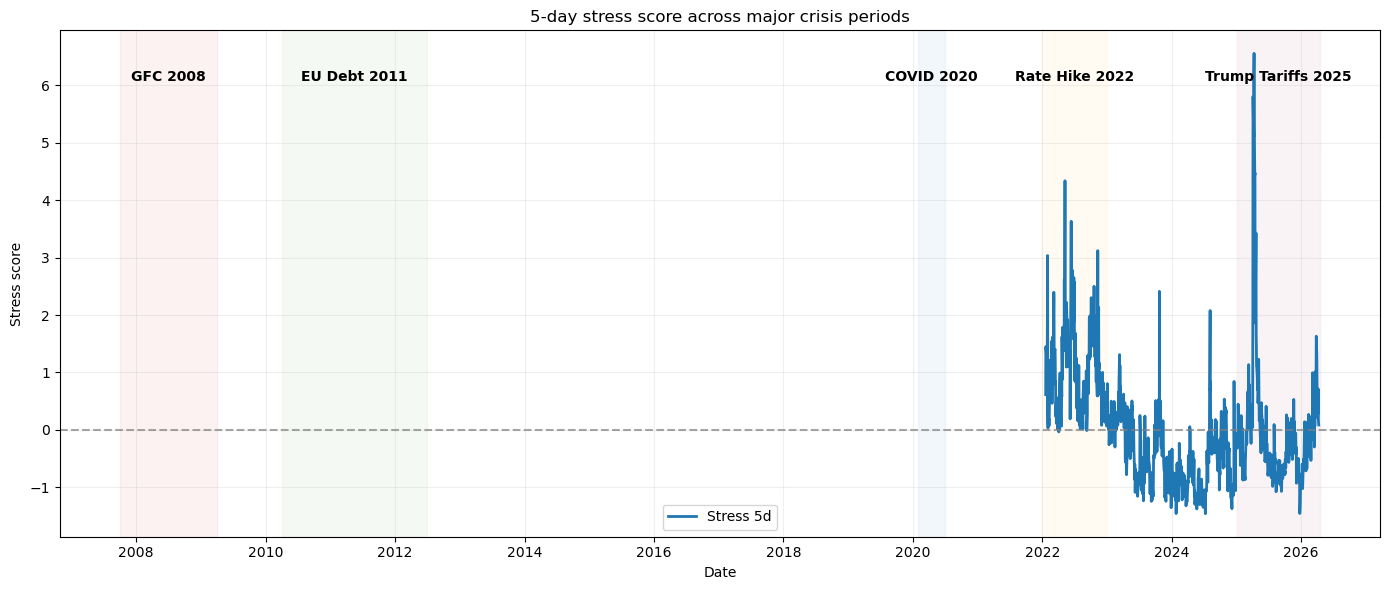

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Major crisis windows
crisis_windows = {
    "GFC 2008": ("2007-10-01", "2009-03-31"),
    "EU Debt 2011": ("2010-04-01", "2012-06-30"),
    "COVID 2020": ("2020-02-01", "2020-06-30"),
    "Rate Hike 2022": ("2022-01-01", "2022-12-31"),
    "Trump Tariffs 2025": ("2025-01-01", "2026-04-17"),
}

# Use your stress series
stress_series = all_results[5]["stress"]

fig, ax = plt.subplots(figsize=(14, 6))

# Plot stress score
ax.plot(stress_series.index, stress_series, color="#1f77b4", linewidth=2, label="Stress 5d")

# Add zero line
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)

# Shade crisis periods
colors = ["#f4cccc", "#d9ead3", "#cfe2f3", "#fff2cc", "#ead1dc"]

for i, (name, (start, end)) in enumerate(crisis_windows.items()):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    ax.axvspan(start, end, color=colors[i], alpha=0.25)

    midpoint = start + (end - start) / 2
    ax.text(
        midpoint,
        ax.get_ylim()[1] * 0.9,
        name,
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("5-day stress score across major crisis periods")
ax.set_ylabel("Stress score")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

*We see that the stress score increases during rate hike and trump tarifs*

**Save the stress signal results which will act as an input for the next stages**

In [59]:
stress_1d = all_results[1]["stress"]
stress_5d = all_results[5]["stress"]

stress_data = pd.DataFrame({
    "stress_1d": stress_1d,
    "stress_5d": stress_5d
})

stress_data.to_csv("stress_signals.csv")

In [60]:
stress_1d.head()

Date
2022-01-25    1.020745
2022-01-26    1.290618
2022-01-27    1.410401
2022-01-28    1.015596
2022-01-31    0.231428
Name: stress, dtype: float64

### Build full dataset for stress score

We use the same model and features as before, but instead of splitting the data into training and test sets, we train the model on all available data and generate predictions for all dates.

The purpose of the full-sample stress series is to support downstream tasks such as visualization and exploration of market regimes. It allows us to examine how the stress signal behaves across different historical periods and major market events.

However, this full-sample stress signal should **not be used for performance evaluation or backtesting**, since the model has been trained on the same data it is applied to. This would introduce look-ahead bias and lead to overly optimistic results.

For evaluation and strategy testing, we instead rely on the out-of-sample stress signal (2022–2025), which is generated using a proper train/test split. This ensures that the results reflect realistic performance and are not driven by overfitting.

In [ ]:


def build_full_stress_series(signals, log_returns, horizon, model_config):
    target_name = f"SPY_y_{horizon}d"

    # Build full dataset
    X_full = build_features(signals, log_returns)
    y_full = build_target(log_returns, horizon).rename(target_name)

    data_full = pd.concat([X_full, y_full], axis=1).dropna()

    X_model_full = data_full.drop(columns=[target_name])
    y_model_full = data_full[target_name]

    # Train on full sample
    q10_full, q90_full = build_models(model_config)
    q10_full.fit(X_model_full, y_model_full)
    q90_full.fit(X_model_full, y_model_full)

    # Predict on full sample
    pred_q10_full = q10_full.predict(X_model_full)
    pred_q90_full = q90_full.predict(X_model_full)

    # Fix crossings
    q10_fixed = np.minimum(pred_q10_full, pred_q90_full)
    q90_fixed = np.maximum(pred_q10_full, pred_q90_full)

    # Build spread + stress
    spread_full = q90_fixed - q10_fixed
    stress_full = (spread_full - spread_full.mean()) / spread_full.std()

    # Return as DataFrame
    out = pd.DataFrame(index=X_model_full.index)
    out[f"Q10_{horizon}d"] = q10_fixed
    out[f"Q90_{horizon}d"] = q90_fixed
    out[f"spread_{horizon}d"] = spread_full
    out[f"stress_{horizon}d"] = stress_full

    return out

stress_full_1d = build_full_stress_series(
    signals=signals,
    log_returns=log_returns,
    horizon=1,
    model_config=best_model_config
)

stress_full_5d = build_full_stress_series(
    signals=signals,
    log_returns=log_returns,
    horizon=5,
    model_config=best_model_config
)



In [64]:
stress_full = stress_full_1d.join(stress_full_5d, how="outer")
stress_full.head()


,Q10_1d,Q90_1d,spread_1d,stress_1d,Q10_5d,Q90_5d,spread_5d,stress_5d
Date,,,,,,,,
2005-03-28,-0.007432,0.007179,0.014611,-0.681293,-0.014418,0.013497,0.027915,-0.924628
2005-03-29,-0.010526,0.010220,0.020746,-0.189842,-0.017619,0.019160,0.036779,-0.529657
2005-03-30,-0.007772,0.007092,0.014863,-0.661068,-0.018060,0.013307,0.031368,-0.770801
2005-03-31,-0.008580,0.008065,0.016645,-0.518361,-0.018189,0.018636,0.036825,-0.527635
2005-04-01,-0.008768,0.008434,0.017203,-0.473678,-0.017425,0.020370,0.037795,-0.484373


In [65]:
stress_full.to_csv("data/processed/stress_signals_full.csv")

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------
# Major crisis windows
# -------------------------------------------------
crisis_windows = {
    "GFC 2008": ("2007-10-01", "2009-03-31"),
    "EU Debt 2011": ("2010-04-01", "2012-06-30"),
    "COVID 2020": ("2020-02-01", "2020-06-30"),
    "Rate Hike 2022": ("2022-01-01", "2022-12-31"),
    "Trump Tariffs 2025": ("2025-01-01", "2026-04-17"),
}

crisis_colors = {
    "GFC 2008": "rgba(244, 204, 204, 0.25)",
    "EU Debt 2011": "rgba(217, 234, 211, 0.25)",
    "COVID 2020": "rgba(207, 226, 243, 0.25)",
    "Rate Hike 2022": "rgba(255, 242, 204, 0.25)",
    "Trump Tariffs 2025": "rgba(234, 209, 220, 0.25)",
}

# -------------------------------------------------
# Build full-sample plot dataframe
# Assumes you already created:
#   stress_full
# with columns:
#   stress_1d, stress_5d
# -------------------------------------------------
plot_df = pd.DataFrame({
    "stress_1d": stress_full["stress_1d"],
    "stress_5d": stress_full["stress_5d"]
}).join(signals[["VIX", "MOVE"]], how="left")

plot_df["realized_vol_20"] = log_returns["SPY"].rolling(20).std().reindex(plot_df.index)

# Keep only rows where all series exist
plot_df = plot_df.dropna()

# -------------------------------------------------
# Standardize all series (z-score)
# -------------------------------------------------
plot_z = plot_df[["stress_1d", "stress_5d", "VIX", "MOVE", "realized_vol_20"]].copy()
plot_z = (plot_z - plot_z.mean()) / plot_z.std()

# -------------------------------------------------
# Plotly figure
# -------------------------------------------------
fig = go.Figure()

# Stress 1d
fig.add_trace(go.Scatter(
    x=plot_z.index,
    y=plot_z["stress_1d"],
    mode="lines",
    name="Stress 1d",
    line=dict(color="black", width=1),
    opacity=0.6
))

# Stress 5d
fig.add_trace(go.Scatter(
    x=plot_z.index,
    y=plot_z["stress_5d"],
    mode="lines",
    name="Stress 5d",
    line=dict(color="#1f77b4", width=2)
))

# VIX
fig.add_trace(go.Scatter(
    x=plot_z.index,
    y=plot_z["VIX"],
    mode="lines",
    name="VIX",
    line=dict(color="#d62728", width=2, dash="dash")
))

# MOVE
fig.add_trace(go.Scatter(
    x=plot_z.index,
    y=plot_z["MOVE"],
    mode="lines",
    name="MOVE",
    line=dict(color="#2ca02c", width=2, dash="dot")
))

# Realized vol
fig.add_trace(go.Scatter(
    x=plot_z.index,
    y=plot_z["realized_vol_20"],
    mode="lines",
    name="Realized Vol 20d",
    line=dict(color="#ff7f0e", width=2, dash="longdash")
))

# -------------------------------------------------
# Add zero line
# -------------------------------------------------
fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="gray",
    opacity=0.6
)

# -------------------------------------------------
# Add shaded crisis windows + labels
# -------------------------------------------------
for name, (start, end) in crisis_windows.items():
    fig.add_vrect(
        x0=start,
        x1=end,
        fillcolor=crisis_colors[name],
        opacity=0.9,
        line_width=0,
        annotation_text=name,
        annotation_position="top left"
    )

# -------------------------------------------------
# Layout
# -------------------------------------------------
fig.update_layout(
    title="Standardized comparison: Stress, VIX, MOVE and Realized Volatility across major crisis periods<br><sup>Click legend items to remove or add lines</sup>",
    xaxis_title="Date",
    yaxis_title="Z-score",
    template="plotly_white",
    height=700,
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor="rgba(255,255,255,0.7)"
    )
)

fig.show()

### End notes for Steps 3 and 4

We have created stress signals that measure market uncertainty.

There are two versions of the stress signal:

1. **Full-sample stress (2007–2025):**  
   Generated by training the model on all available data. This version is used for visualization and exploration of market regimes, and can support strategy development and feature understanding.

2. **Test-period stress (2022–2025):**  
   Generated using a proper train/test split. This version is used for final evaluation and backtesting, ensuring that results are out-of-sample and not affected by overfitting.

The **5-day stress signal** is the main signal, as it provides a more stable and interpretable measure of market conditions. The **1-day stress signal** is included for comparison and robustness testing, as it is more reactive but also noisier.

In Step 4, the stress signal should be used as an input to control portfolio allocation, shifting between risk-on and risk-off strategies depending on the level of market uncertainty.

#### How to use the data

- Use the **full-sample stress signal** for:
  - understanding patterns
  - exploring stress regimes
  - developing decision rules

- Use the **test-period stress signal (2022–2025)** for:
  - backtesting strategies
  - evaluating performance
  - comparing models

> Important: Do **not** evaluate performance on the full-sample stress signal, as this would introduce look-ahead bias.

#### Files provided

- Full-sample stress (for exploration and development):
```python
stress_full.to_csv("data/processed/stress_signals_full.csv")